In [1]:
import datetime
import os
from functools import partial
from itertools import product
from pathlib import Path
from string import ascii_lowercase

import colormaps
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import polars.selectors as cs
import xarray as xr
from matplotlib.cm import ScalarMappable
from matplotlib.colors import (
    BoundaryNorm,
    LinearSegmentedColormap,
    Normalize,
    hsv_to_rgb,
    rgb_to_hsv,
)
from matplotlib.dates import DateFormatter
from matplotlib.ticker import MaxNLocator
from scipy.stats import gaussian_kde
from tqdm import tqdm

os.environ["PATH"] = os.environ["PATH"] + ":/opt/homebrew/bin"

import altair as alt
from jetutils.anyspell import (
    extend_spells,
    get_spells,
    make_daily,
    mask_from_spells_pl,
    subset_around_onset,
)
from jetutils.data import compute_anomalies_pl, standardize, periodic_rolling_pl
from jetutils.definitions import (
    DATADIR,
    DUNCANS_REGIONS_NAMES,
    FACTORS,
    FACTORS_UNITS,
    FIGURES,
    MONTH_NAMES,
    PRETTIER_VARNAME,
    UNITS,
    YEARS,
    get_region,
    polars_to_xarray,
    squarify,
)
from jetutils.geospatial import (
    central_diff,
    compute_relative_anom,
    compute_relative_clim,
    compute_relative_sm,
)
from jetutils.jet_finding import (
    average_jet_categories,
    extract_features,
    jet_position_as_da,
    pers_from_cross_catd,
    spells_from_cross_catd_simple,
    to_one_large,
)
from jetutils.plots import (
    COLORS,
    COLORS_EXT,
    STYLE_SHEET,
    TEXTWIDTH_IN,
    WERNLI_FLAIR,
    Clusterplot,
    plot_interp,
)
from jetutils.stats import create_bootstrapped_times

alt.data_transformers.enable("vegafusion")

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches':None}

basepath = Path(f"{DATADIR}/exp10")

No shap


In [2]:
ALL_TIMES = (
    pl.datetime_range(
        start=pl.datetime(1959, 1, 1),
        end=pl.datetime(2023, 1, 1),
        closed="left",
        interval="6h",
        eager=True,
        time_unit="ms",
    )
    .rename("time")
    .to_frame()
)
summer_filter = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9])).filter(
    pl.col("time").dt.ordinal_day() > 166
)
summer = summer_filter["time"]
summer_daily = summer.filter(summer.dt.hour() == 0)
big_summer = ALL_TIMES.filter(pl.col("time").dt.month().is_in([6, 7, 8, 9]))
big_summer_daily = big_summer.filter(big_summer["time"].dt.hour() == 0)

summer_doy = summer_daily.dt.ordinal_day().unique()
n_bootstraps = 100

jets = pl.read_parquet(basepath.joinpath("jets.parquet"))
phat_jets = to_one_large(jets, int_EDJ_threshold=1.3e8)
props_uncat = pl.read_parquet(basepath.joinpath("props.parquet"))
props_uncat = props_uncat.with_columns(
    cs.exclude("time", "jet ID")
    .cast(pl.Float32())
    .replace((float("-inf"), float("inf"), float("nan")), None)
    .cast(pl.Float32())
)
props = squarify(average_jet_categories(props_uncat), ["time", "jet"])
phat_filter = (pl.col("is_polar") < 0.5) | (
    (pl.col("is_polar") > 0.5) & (pl.col("int") > 1.3e8)
)
phat_props = props_uncat.filter(phat_filter)
index_columns = ["time", "jet ID"]
phat_props = squarify(average_jet_categories(phat_props), ["time", "jet"])
cross = pl.read_parquet(basepath.joinpath("cross.parquet"))
cross = cross.filter(pl.col("jet ID") == pl.col("jet ID_right"))
cross = pers_from_cross_catd(cross)
pers = cross.select(
    "time",
    jet=pl.when(pl.col("jet ID") == 0).then(pl.lit("STJ")).otherwise(pl.lit("EDJ")),
    pers="pers",
)
phat_props = phat_props.join(pers, on=["time", "jet"], how="left")
phat_props = phat_props.with_columns(
    cs.exclude("time", "jet")
    .cast(pl.Float32())
    .replace((float("-inf"), float("inf"), float("nan")), None)
    .cast(pl.Float32())
)
phat_props = phat_props.join(
    phat_props.rolling("time", period="2d", group_by="jet").agg(
        **{
            f"{col}_var": pl.col(col).var()
            for col in ["mean_lon", "mean_lat", "mean_s", "s_star"]
        }
    ),
    on=["time", "jet"],
)
cross = pl.read_parquet(basepath.joinpath("cross.parquet"))

phat_props_summer = summer_filter.join(phat_props, on="time")

spells_list = spells_from_cross_catd_simple(
    cross,
    season=summer,
    q_STJ=0.705,
    q_EDJ=0.836,
    minlen=datetime.timedelta(days=5),
    smooth=datetime.timedelta(hours=24),
    fill_holes=datetime.timedelta(hours=18),
)

for jet, spells in spells_list.items():
    print(jet, spells["spell"].n_unique())

daily_spells_list = {
    a: make_daily(b, "spell", ["len", "spell_of"]) for a, b in spells_list.items()
}

STJ 30
EDJ 30


# Is EMF relevant?

In [5]:
df = pl.read_parquet(basepath.joinpath("hor_relative.parquet"))

In [ ]:
df_summer = df.drop("is_polar", "hor1_interp", "hor2_interp").filter(
    pl.col("time").dt.month().is_in([6, 7, 8, 9])
)
df_spells = (
    spells_list["EDJ"].join(df_summer, on="time").drop("spell", "relative_index")
)

ds = polars_to_xarray(df_summer, ["time", "jet ID", "norm_index", "n"])
ds_spells = polars_to_xarray(df_spells, ["time", "jet ID", "norm_index", "n"])

In [7]:
ds_clim = ds.groupby("time.dayofyear").mean()

In [ ]:
from jetutils.data import smooth

ds_clim = smooth(ds_clim, {"dayofyear": ("win", 25)})

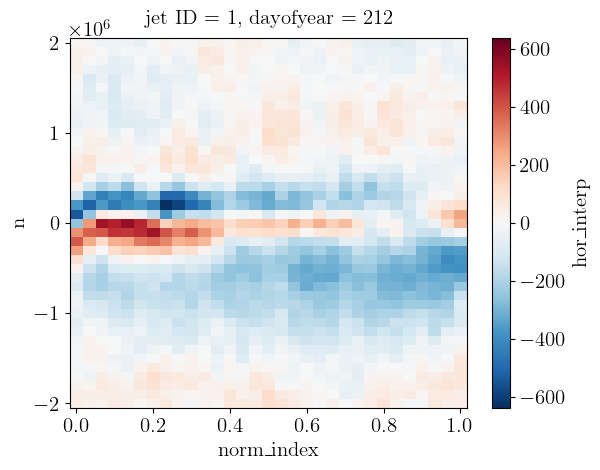

In [14]:
ds_clim[60, 1].T.plot()

In [15]:
ds_spells

<xarray.Dataset> Size: 129MB
Dimensions:        (time: 846, jet ID: 2, norm_index: 31, n: 41)
Coordinates:
  * time           (time) datetime64[ms] 7kB 1962-08-08T12:00:00 ... 2020-09-...
  * jet ID         (jet ID) uint32 8B 0 1
  * norm_index     (norm_index) float32 124B 0.0 0.03333 0.06667 ... 0.9667 1.0
  * n              (n) float32 164B -2e+06 -1.9e+06 -1.8e+06 ... 1.9e+06 2e+06
Data variables:
    len            (time, jet ID, norm_index, n) float64 17MB 24.0 24.0 ... nan
    relative_time  (time, jet ID, norm_index, n) timedelta64[ms] 17MB 00:00:0...
    start          (time, jet ID, norm_index, n) float64 17MB 1.502e+03 ... nan
    value          (time, jet ID, norm_index, n) object 17MB True True ... nan
    index          (time, jet ID, norm_index, n) float64 17MB 1.502e+03 ... nan
    pers           (time, jet ID, norm_index, n) float64 17MB 0.03534 ... nan
    spell_of       (time, jet ID, norm_index, n) object 17MB 'EDJ' 'EDJ' ... nan
    hor_interp     (time, jet ID, norm_index, n) float32 9MB 1.899e+03 ... nan

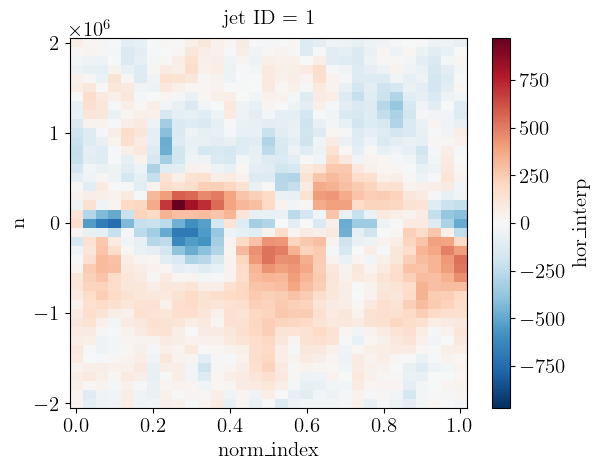

In [16]:
(-ds_spells.mean("time")["hor_interp"][1]).T.plot()

# jet pos

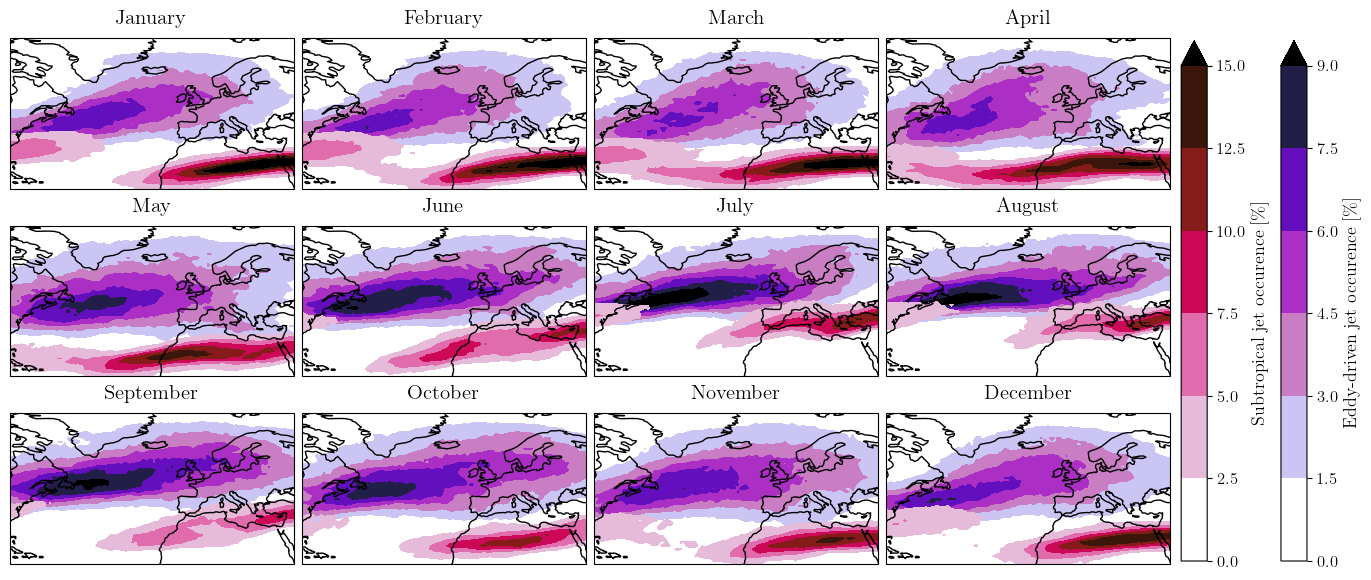

In [ ]:
jet_pos_da = jet_position_as_da(jets)

plt.ion()
MYPURPLES = LinearSegmentedColormap.from_list(
    "mypurples", ["#ffffff", COLORS_EXT[4], COLORS_EXT[5]]
)
MYPINKS = LinearSegmentedColormap.from_list(
    "mypinks", ["#ffffff", COLORS_EXT[7], COLORS_EXT[8]]
)

to_plot_1 = []
to_plot_2 = []
for month in range(1, 13):
    this_da = jet_pos_da.sel(time=jet_pos_da.time.dt.month == month)
    to_plot_1.append((this_da < 0.5).mean("time"))
    to_plot_2.append((this_da > 0.5).mean("time"))

clu = Clusterplot(3, 4, get_region(jet_pos_da), row_height=3.4)
im, kwargs = clu.add_contourf(
    [tp2 * 100 for tp2 in to_plot_2],
    transparify=1,
    levels=7,
    q=0.995,
    cmap=colormaps.gothic_r,
    draw_cbar=False,
    titles=MONTH_NAMES,
)
cbar = clu.fig.colorbar(im, ax=clu.axes, shrink=0.99, pad=0.01)
cbar.ax.set_ylabel(r"Eddy-driven jet occurence [$\%$]", fontsize=13)
im, kwargs = clu.add_contourf(
    [tp1 * 100 for tp1 in to_plot_1],
    transparify=1,
    levels=7,
    q=0.995,
    cmap=colormaps.flamingo_r,
    draw_cbar=False,
)
cbar = clu.fig.colorbar(im, ax=clu.axes, shrink=0.99, pad=0.01)
cbar.ax.set_ylabel(r"Subtropical jet occurence [\%]", fontsize=13)
clu.resize_relative([1.0, 1.06])

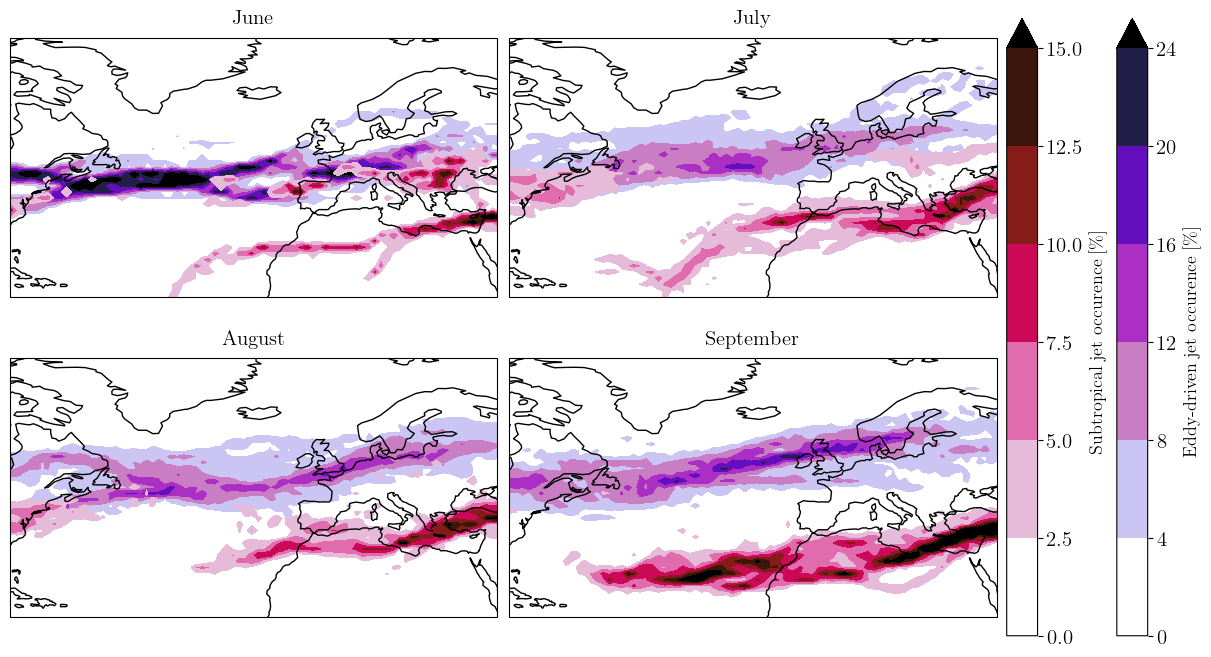

In [ ]:
jet_pos_da_eps = jet_position_as_da(
    spells_list["EDJ"]
    .join(jets.cast({"time": pl.Datetime("ms")}), on="time")
    .drop("spell", "relative_index")
)
plt.ion()
MYPURPLES = LinearSegmentedColormap.from_list(
    "mypurples", ["#ffffff", COLORS_EXT[4], COLORS_EXT[5]]
)
MYPINKS = LinearSegmentedColormap.from_list(
    "mypinks", ["#ffffff", COLORS_EXT[7], COLORS_EXT[8]]
)

to_plot_1 = []
to_plot_2 = []
for month in range(6, 10):
    this_da = jet_pos_da_eps.sel(time=jet_pos_da_eps.time.dt.month == month)
    to_plot_1.append((this_da < 0.5).mean("time"))
    to_plot_2.append((this_da > 0.5).mean("time"))

clu = Clusterplot(2, 2, get_region(jet_pos_da_eps), row_height=6)
im, kwargs = clu.add_contourf(
    [tp2 * 100 for tp2 in to_plot_2],
    transparify=1,
    levels=7,
    q=0.995,
    cmap=colormaps.gothic_r,
    draw_cbar=False,
    titles=MONTH_NAMES[5:],
)
cbar = clu.fig.colorbar(im, ax=clu.axes, shrink=0.99, pad=0.01)
cbar.ax.set_ylabel(r"Eddy-driven jet occurence [$\%$]", fontsize=13)
im, kwargs = clu.add_contourf(
    [tp1 * 100 for tp1 in to_plot_1],
    transparify=1,
    levels=7,
    q=0.995,
    cmap=colormaps.flamingo_r,
    draw_cbar=False,
)
cbar = clu.fig.colorbar(im, ax=clu.axes, shrink=0.99, pad=0.01)
cbar.ax.set_ylabel(r"Subtropical jet occurence [\%]", fontsize=13)
clu.resize_relative([1.0, 1.06])

# indiv spells

In [ ]:
summer_doy = summer_daily.dt.ordinal_day().unique()
n_bootstraps = 100

cold = pl.col("n") >= 0
warm = pl.col("n") <= 0
reduced = pl.col("n").abs() <= 1e6
mid = [pl.col("norm_index") >= 0.33, pl.col("norm_index") <= 0.66]
entrance = pl.col("norm_index") <= 0.33
exit_ = pl.col("norm_index") >= 0.66

all_region_filters = {
    "cold": [cold, reduced],
    "warm": [warm, reduced],
    "cold_entrance": [cold, entrance, reduced],
    "warm_entrance": [warm, entrance, reduced],
    "cold_mid": [cold, *mid, reduced],
    "warm_mid": [warm, *mid, reduced],
    "cold_exit": [cold, exit_, reduced],
    "warm_exit": [warm, exit_, reduced],
    "core": [pl.col("n").abs() <= 5e5],
    "warm_far": [pl.col("n") <= -1.2e6, pl.col("norm_index") <= 0.5],
}
filters_for_variables = {
    "APVO": ["cold", "warm"],
    "CPVO": ["cold", "warm"],
    "t2m": ["cold_mid", "warm_mid", "cold", "warm"],
    "tp": [
        "warm_entrance",
        "warm_mid",
        "cold_mid",
        "cold_exit",
        "cold",
        "warm",
        "warm_far",
    ],
    "theta": [
        "cold_mid",
        "warm_mid",
        "cold_exit",
        "warm_exit",
        "cold_entrance",
        "warm_entrance",
        "cold",
        "warm",
    ],
    "EKE250": ["cold", "warm", "core"],
    "hor": ["cold", "warm", "core"],
}
time_filters = {
    "before": [
        pl.col("relative_time") < pl.duration(days=0),
        pl.col("relative_time") >= pl.duration(days=-4),
    ],
    "during": [
        pl.col("relative_time") >= pl.duration(days=0),
        pl.col("relative_time") <= pl.duration(days=5),
    ],
}

props_to_take = [
    "mean_lon",
    "mean_lat",
    "mean_theta",
    "mean_s",
    "tilt",
    "waviness1",
    "waviness2",
    "wavinessR16",
    "int",
    "width",
    # "mjo_pc1",
    # "mjo_pc2",
    # "mjo_int",
    # "lat_over_europe",
]
do_anom = {
    "APVO": False,
    "CPVO": False,
    "t2m": True,
    "tp": False,
    "theta": True,
    "EKE250": True,
    "hor": True,
} | {prop: True for prop in props_to_take}

relative_dfs = {}
clims = {}
clims_std = {}
clims_sm = {}
for varname in tqdm(filters_for_variables):
    df = summer_filter.lazy().join(
        pl.scan_parquet(basepath.joinpath(f"{varname}_relative.parquet"))
        .cast({"time": pl.Datetime("ms")})
        .filter(pl.col("n") % 1e5 == 0),
        on="time",
    )
    if varname == "hor":
        df = df.drop("hor1_interp", "hor2_interp")
    relative_dfs[varname] = df
    clim = (
        df.group_by(
            pl.col("time").dt.ordinal_day().alias("dayofyear"),
            "norm_index",
            "n",
            "jet ID",
        )
        .agg(pl.col(f"{varname}_interp").mean())
        .sort("jet ID", "dayofyear", "norm_index", "n")
        .collect()
    )
    clims[varname] = clim
    clim_std = (
        df.group_by(
            pl.col("time").dt.ordinal_day().alias("dayofyear"),
            "norm_index",
            "n",
            "jet ID",
        )
        .agg(pl.col(f"{varname}_interp").std())
        .sort("jet ID", "dayofyear", "norm_index", "n")
        .collect()
    )
    clims_std[varname] = clim_std
    clim_sm = clim.with_columns(
        **{
            f"{varname}_interp": pl.col(f"{varname}_interp")
            .filter(pl.col("dayofyear").is_in(summer_doy.implode()))
            .mean()
            .over("jet ID", "n", "norm_index")
        }
    )
    clims_sm[varname] = clim_sm

selector = (
    cs.all()
    .exclude("time", "jet")
    .cast(pl.Float32())
    .replace((float("-inf"), float("inf"), float("nan")), None)
    .cast(pl.Float32())
)
filter_ = pl.col("time").dt.month().is_in([6, 7, 8, 9])
props_anoms = phat_props.with_columns(
    (
        (selector - selector.filter(filter_).mean()) / selector.filter(filter_).std()
    ).over("jet")
)

# # mjo = (
# #     pl.from_pandas(
# #         pd.read_fwf(
# #             f"{DATADIR}/era5_mjo.txt",
# #             header=None,
# #             names=[
# #                 "year",
# #                 "month",
# #                 "day",
# #                 "mjo_pc1",
# #                 "mjo_pc2",
# #                 "mjo_phase",
# #                 "mjo_int",
# #             ],
# #             infer_nrows=100000,
# #         )
# #     )
# #     .with_columns(
# #         time=pl.datetime(
# #             year=pl.col("year"),
# #             month=pl.col("month"),
# #             day=pl.col("day"),
# #             time_unit="ms",
# #         )
# #     )
# #     .drop(["year", "month", "day"])
# # )
# # mjo = mjo.with_columns(
# #     (pl.col("mjo_int") - pl.col("mjo_int").min())
# #     / (pl.col("mjo_int").max() - pl.col("mjo_int").min())
# #     * 100
# # )

grams_wr = pl.read_parquet(f"{DATADIR}/grams_wr.parquet")
grams_wr = grams_wr.cast({"time": pl.Datetime("ms")})
winner_names = pl.DataFrame(
    {"winner": list(range(5)), "name": ["No", "GB", "AL", "AR", "SB"]}
)
grams_wr = grams_wr.join(winner_names, on="winner")

# # props_anoms = props_anoms.join(mjo.cast({"time": pl.Datetime("ms")}), on="time")

100%|██████████| 7/7 [01:00<00:00,  8.63s/it]


In [ ]:
everything = {"STJ": None, "EDJ": None}
factors = {"tp": 1000, "APVO": 100, "CPVO": 100}
for jet in ["STJ", "EDJ"]:
    id_ = int(jet == "EDJ")
    dayofyears = spells_list[f"{jet}"]["time"].dt.ordinal_day()
    spells = spells_list[f"{jet}"]
    to_ret = spells["spell"].unique().to_frame()
    to_ret = pl.concat(
        [
            to_ret.cast({"spell": pl.Int32()}),
            pl.DataFrame({"spell": [-2, -1]}).cast({"spell": pl.Int32()}),
        ]
    )
    everything[jet] = to_ret.clone()
    spells_ext = extend_spells(spells, time_before=datetime.timedelta(days=4))
    for varname, these_filters in tqdm(filters_for_variables.items()):
        clim = clims[varname]
        clim_sm = clims_sm[varname].filter(pl.col("jet ID") == bool(id_))
        clim_std = clims_std[varname]
        this_do_anom = do_anom[varname]
        space_filters = {
            filter_name: all_region_filters[filter_name]
            for filter_name in these_filters
        }
        these_filters = {
            f"{filter_name}_{when_}": [*filter_, *time_filter_]
            for filter_name, filter_ in space_filters.items()
            for when_, time_filter_ in time_filters.items()
        }
        # ts_bootstrapped = create_bootstrapped_times(spells_ext, summer_daily, n_bootstraps)
        masked = (
            spells_ext.lazy()
            .join(
                relative_dfs[varname],
                on="time",
            )
            .collect()
        )
        varname_ = f"{varname}_interp"
        agg = (
            pl.col(varname_)
            .replace([float("inf"), float("-inf"), float("nan")], None)
            .mean()
            .cast(pl.Float32())
        )
        factor = factors.get(varname, 1)
        filter_name = list(these_filters)[0]
        if this_do_anom:
            masked = (
                masked.with_columns(dayofyear=pl.col("time").dt.ordinal_day())
                .join(clim, on=["jet ID", "dayofyear", "norm_index", "n"])
                .with_columns(pl.col(varname_) - pl.col(f"{varname_}_right"))
                .drop(f"{varname_}_right")
                .join(clim_std, on=["jet ID", "dayofyear", "norm_index", "n"])
                .with_columns(pl.col(varname_) / pl.col(f"{varname_}_right"))
                .drop(f"{varname_}_right", "dayofyear")
            )
            agg_clim = pl.lit(0.0, dtype=pl.Float32())
        else:
            agg_clim = agg
        for filter_name, filter_ in these_filters.items():
            # results = squarify(results, ["spell"])
            full_name = f"{varname}_{filter_name}"
            results = (
                masked.filter(pl.col("jet ID") == id_, *filter_)
                .group_by("spell")
                .agg(**{full_name: agg * factor})
                .sort("spell")
                .cast({"spell": pl.Int32()})
            )
            # full_name_pvals = f"{full_name}_pvals"
            # results = results.group_by("spell", maintain_order=True).agg(
            #     **{
            #         full_name: pl.col(varname_).last() * factor,
            #         full_name_pvals: (pl.col(varname_).rank().last() - 1) / n_bootstraps
            #     }
            # ).cast({"spell": pl.Int32()})
            space_filter = space_filters[filter_name.split("_")[0]]
            mean_over_spells = results.select(
                **{
                    "spell": -2,
                    full_name: pl.col(full_name).mean(),
                    # full_name_pvals: pl.col(full_name_pvals).mean(),
                }
            )
            clim_ = clim_sm.filter(pl.col("dayofyear") == 1, *space_filter).select(
                **{
                    "spell": -1,
                    full_name: agg_clim * factor,
                    # full_name_pvals: pl.lit(0.5, dtype=pl.Float32()),
                }
            )
            results = pl.concat([results, mean_over_spells, clim_])
            everything[jet] = everything[jet].join(results, on="spell", how="left")
    for when_, time_filter_ in time_filters.items():
        # masked_props = (
        #     ts_bootstrapped
        #     .join(props_anoms, on="time")
        #     .filter(*time_filter_, pl.col("jet") == jet)
        #     .group_by("sample_index", "spell")
        #     .agg(**{f"{prop}_{when_}": pl.col(prop).mean().cast(pl.Float32()) for prop in props_to_take})
        #     .sort("sample_index", "spell")
        # )
        masked_props = (
            spells_ext.join(props_anoms, on="time")
            .filter(*time_filter_, pl.col("jet") == jet)
            .group_by("spell")
            .agg(
                **{
                    f"{prop}_{when_}": pl.col(prop).mean().cast(pl.Float32())
                    for prop in props_to_take
                }
            )
            .sort("spell")
        )
        # theseprops = masked_props.filter(pl.col("sample_index") == n_bootstraps).drop("sample_index")
        mean_over_spells = masked_props.select(cs.all().mean()).with_columns(spell=-2)
        clim_ = pl.DataFrame(
            {
                "spell": -1,
                **{f"{name}_{when_}": np.float32(0.0) for name in props_to_take},
            }
        ).cast({"spell": pl.Int32()})

        theseprops = pl.concat(
            [masked_props.cast({"spell": pl.Int32()}), mean_over_spells, clim_]
        )

        # thesepvals = masked_props.group_by("spell", maintain_order=True).agg(**{f"{prop}_{when_}_pvals": ((pl.col(f"{prop}_{when_}").rank().last() - 1) / n_bootstraps).cast(pl.Float64()) for prop in props_to_take})
        # mean_over_spells = thesepvals.select(cs.all().mean()).with_columns(spell=-2)
        # clim_ = pl.DataFrame({"spell": -1, **{f"{name}_{when_}_pvals": 0.5 for name in props_to_take}}).cast({"spell": pl.Int32()})
        # thesepvals = pl.concat([thesepvals.cast({"spell": pl.Int32()}), mean_over_spells, clim_])

        everything[jet] = everything[jet].join(theseprops, on="spell", how="left")
        # everything[jet] = everything[jet].join(thesepvals, on="spell", how="left")

    # phase_stuff = (
    #     spells_ext.join(mjo, on="time")
    #     .group_by("spell")
    #     .agg(
    #         **{
    #             f"mjo_phase_{when_}": pl.col("mjo_phase")
    #             .filter(time_filter_)
    #             .mode()
    #             .first()
    #             for when_, time_filter_ in time_filters.items()
    #         }
    #     )
    #     .sort("spell")
    # )
    # everything[jet] = everything[jet].join(phase_stuff, on="spell", how="left")

    regime_stuff = (
        spells_ext.join(grams_wr, on="time")
        .group_by("spell")
        .agg(
            **{
                f"regime_{when}": pl.col("winner")
                .filter(*time_filter_, pl.col("winner") != 0)
                .mode()
                .first()
                for when, time_filter_ in time_filters.items()
            }
        )
    )
    everything[jet] = everything[jet].join(regime_stuff, on="spell", how="left")
    regime_stuff = (
        spells_ext.join(grams_wr, on="time")
        .group_by("spell")
        .agg(
            **{
                f"regime_withno_{when}": pl.col("winner")
                .filter(time_filter_)
                .mode()
                .first()
                for when, time_filter_ in time_filters.items()
            }
        )
    )
    everything[jet] = everything[jet].join(regime_stuff, on="spell", how="left")
    everything[jet].write_parquet(
        f"{FIGURES}/Persistence/figure_data/everything_{jet}.parquet"
    )

100%|██████████| 7/7 [00:16<00:00,  2.43s/it]


/var/folders/zb/qrvsjg590771qgw5yhnx1vmw0000gn/T/ipykernel_46699/336440927.py:214: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  height_ratios[i] = count[j]
/var/folders/zb/qrvsjg590771qgw5yhnx1vmw0000gn/T/ipykernel_46699/336440927.py:214: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  height_ratios[i] = count[j]


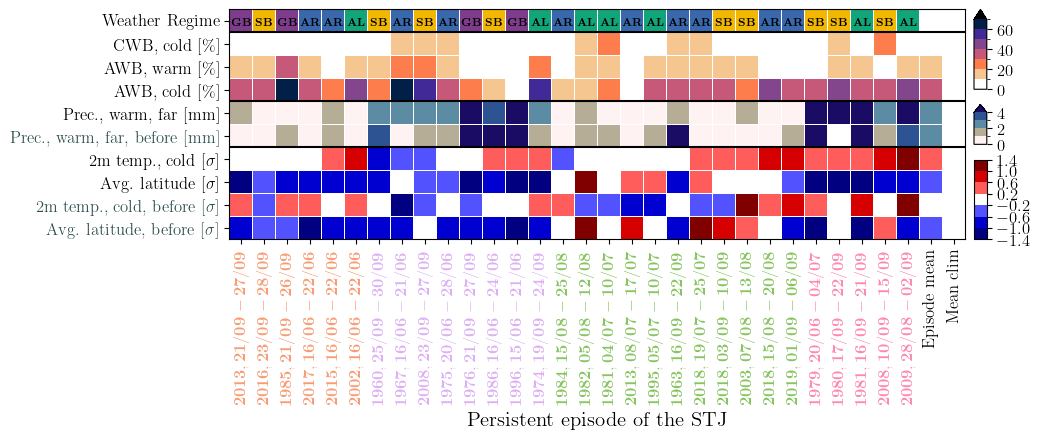

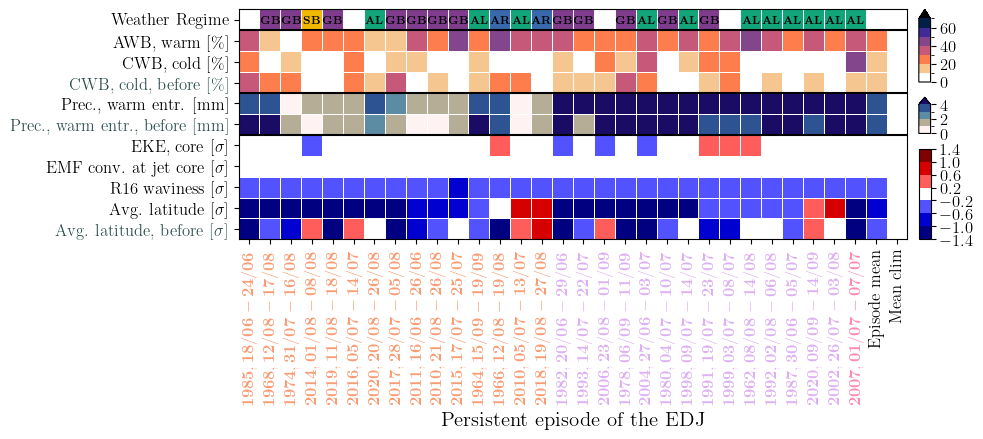

In [14]:
from pathlib import Path
from string import ascii_uppercase

from sklearn.decomposition import PCA

%matplotlib inline
%config InlineBackend.print_figure_kwargs = {'bbox_inches': "tight"}
# %config InlineBackend.print_figure_kwargs = {'bbox_inches': None}


everything_stj = pl.read_parquet(
    f"{FIGURES}/Persistence/figure_data/everything_STJ.parquet"
)
everything_edj = pl.read_parquet(
    f"{FIGURES}/Persistence/figure_data/everything_EDJ.parquet"
)
winner_names = pl.DataFrame(
    {"winner": list(range(5)), "name": ["No", "GB", "AL", "AR", "SB"]}
)

plt.rc("xtick", labelsize=12)
plt.rc("ytick", labelsize=12)
plt.rc("savefig", bbox="tight")
# plt.rc("savefig", bbox=None)
when = "during"

relevant_keys_STJ = {
    "mean_lat_before": ["anom", PRETTIER_VARNAME["mean_lat"] + ", before", r"$\sigma$"],
    # "theta2PVU_cold_before": ["anom", r"$\theta$ at 2PVU, cold, before", r"$\sigma$"],
    # "theta2PVU_warm_before": ["anom", r"$\theta$ at 2PVU, warm, before", r"$\sigma$"],
    "t2m_cold_before": ["anom", "2m temp., cold, before", r"$\sigma$"],
    # "t2m_warm_before": ["anom", "2m temp., warm, before", r"$\sigma$"],
    "mean_lat_during": ["anom", PRETTIER_VARNAME["mean_lat"], r"$\sigma$"],
    # "theta2PVU_cold_during": ["anom", r"$\theta$ at 2PVU, cold", r"$\sigma$"],
    # "theta2PVU_warm_during": ["anom", r"$\theta$ at 2PVU, warm", r"$\sigma$"],
    "t2m_cold_during": ["anom", "2m temp., cold", r"$\sigma$"],
    # "EKE250_cold_during": ["anom", "EKE, cold", r"$\sigma$"],
    # "t2m_warm_during": ["anom", "2m temp., warm", r"$\sigma$"],
    # "tp_cold_during": ["abs", "Prec., cold", r"mm"],
    "tp_warm_far_before": ["abs", "Prec., warm, far, before", r"mm"],
    "tp_warm_far_during": ["abs", "Prec., warm, far", r"mm"],
    "APVO_cold_during": ["zeroone", "AWB, cold", r"$\%$"],
    "APVO_warm_during": ["zeroone", "AWB, warm", r"$\%$"],
    "CPVO_cold_during": ["zeroone", "CWB, cold", r"$\%$"],
}

pvals_STJ = [f"{key}_pvals" for key in relevant_keys_STJ]
relevant_keys_STJ = {
    key: [type_, f"{val} [{unit}]"]
    for key, (type_, val, unit) in relevant_keys_STJ.items()
}

relevant_keys_EDJ = {
    "mean_lat_before": ["anom", PRETTIER_VARNAME["mean_lat"] + ", before", r"$\sigma$"],
    # "theta2PVU_cold_before": ["anom", r"$\theta$ at 2PVU, cold, before", r"$\sigma$"],
    # "theta2PVU_warm_before": ["anom", r"$\theta$ at 2PVU, warm, before", r"$\sigma$"],
    "mean_lat_during": ["anom", PRETTIER_VARNAME["mean_lat"], r"$\sigma$"],
    # "lat_over_europe_during": ["anom", "Latitude over Europe", r"$\sigma$"],
    "wavinessR16_during": ["anom", PRETTIER_VARNAME["wavinessR16"], r"$\sigma$"],
    # "theta2PVU_cold_during": ["anom", r"$\theta$ at 2PVU, cold", r"$\sigma$"],
    # "theta2PVU_warm_during": ["anom", r"$\theta$ at 2PVU, warm", r"$\sigma$"],
    # "t2m_cold_during": ["anom", "2m temp., cold", r"$\sigma$"],
    # "t2m_warm_during": ["anom", "2m temp., warm", r"$\sigma$"],
    "hor_core_during": ["anom", "EMF conv. at jet core", r"$\sigma$"],
    "EKE250_core_during": ["anom", "EKE, core", r"$\sigma$"],
    # "EKE250_warm_during": ["anom", "EKE, warm", r"$\sigma$"],
    "tp_warm_entrance_before": ["abs", "Prec., warm entr., before", r"mm"],
    "tp_warm_entrance_during": ["abs", "Prec., warm entr.", r"mm"],
    # "zblocks_warm_before": ["zeroone", "Blocks, warm, before", r"$\%$"],
    "CPVO_cold_before": ["zeroone", "CWB, cold, before", r"$\%$"],
    # "SCPVS_warm_before": ["zeroone", "CWB, warm, before", r"$\%$"],
    # "zblocks_warm_during": ["zeroone", "Blocks, warm flank", r"$\%$"],
    "CPVO_cold_during": ["zeroone", "CWB, cold", r"$\%$"],
    "APVO_warm_during": ["zeroone", "AWB, warm", r"$\%$"],
    # "SCPVS_warm_during": ["zeroone", "CWB, warm flank", r"$\%$"],
    # "SAPVS_warm_during": ["zeroone", "AWB, warm flank", r"$\%$"],
}

pvals_EDJ = [f"{key}_pvals" for key in relevant_keys_EDJ]
relevant_keys_EDJ = {
    key: [type_, f"{val} [{unit}]"]
    for key, (type_, val, unit) in relevant_keys_EDJ.items()
}

# danom = 0.6
levels_anom = np.array([-1.4, -1.0, -0.6, -0.2, 0.2, 0.6, 1.0, 1.4])
levels_anom = levels_anom[np.round(levels_anom, 10) != 0]
plot_kwargs = {
    "anom": {
        "cmap": colormaps.BlWhRe,
        "norm": BoundaryNorm(levels_anom, colormaps.BlWhRe.N, extend="neither"),
        "cbar_ticks": levels_anom,
    },
    "abs": {
        "cmap": colormaps.lapaz_r,
        "norm": BoundaryNorm([0, 1, 2, 3, 4], colormaps.lapaz_r.N, extend="max"),
        "cbar_ticks": [0, 2, 4],
    },
    "zeroone": {
        "cmap": colormaps.torch_r,
        "norm": BoundaryNorm(
            [0, 10, 20, 30, 40, 50, 60, 70], colormaps.torch_r.N, extend="max"
        ),
        "cbar_ticks": [0, 20, 40, 60],
    },
}
order_i_want = ["zeroone", "abs", "anom"]


def signif_array(X_pvals: pl.DataFrame, type_: str, alpha: float = 0.05):
    ouais = X_pvals.to_numpy().T[ys[i][:-1]]
    if type_ == "anom":
        ouais = (ouais > 1 - alpha / 2) | (ouais < alpha / 2)
    else:
        ouais = ouais > 1 - alpha
    dummy = np.ones_like(ouais, dtype=float)
    return np.ma.masked_array(dummy, mask=~ouais)


early_summer = ALL_TIMES.filter(
    pl.col("time").dt.month() == 6,
    pl.col("time").dt.day() >= 15,
    pl.col("time").dt.day() <= 25,
)["time"]
late_summer = ALL_TIMES.filter(
    pl.col("time").dt.month() == 9, pl.col("time").dt.day() >= 20
)["time"]

spells_in_early_or_late = {
    jet: spells_list[f"{jet}"]
    .group_by("spell", maintain_order=True)
    .agg(
        is_early=(pl.col("time").is_in(early_summer.implode()).mean() > 0.5)
        | (pl.col("time").is_in(late_summer.implode()).mean() > 0.5)
    )
    for jet in ["STJ", "EDJ"]
}

estj = everything_stj.join(spells_in_early_or_late["STJ"], on="spell", how="left")
filters_stj = {
    "early_late": ~pl.col("is_early"),
    # "warm_cold": (pl.col("t2m_cold_during") > 0.2),
    "enhanced_precip": pl.col("tp_warm_far_during") > 2,
    # "enhanced_ccwb": pl.col("CPVO_cold_during") > 1.1 * pl.col("CPVO_cold_during").last(),
    # "enhanced_cawb": pl.col("APVO_cold_during") > 1.1 * pl.col("APVO_cold_during").last(),
    "t2m_cold_during": "t2m_cold_during",
}
filters_stj = estj.select(pl.col("spell"), **filters_stj)[:-2]

groups_stj = filters_stj.select(
    pl.col("spell"),
    "t2m_cold_during",
    group=pl.concat_str(cs.boolean().cast(pl.UInt8())).str.to_integer(base=2),
)
order_stj = groups_stj.select(
    order=pl.col("spell").sort_by("group", "t2m_cold_during")
)["order"].to_numpy()

# group_1 = filters_stj["early_late"].arg_true()
# group_2 = filters_stj.select(hoho=pl.col("enhanced_precip") & ~pl.col("early_late") & ~pl.col("enhanced_cawb") & ~pl.col("enhanced_ccwb"))["hoho"].arg_true()
# group_2_and_3 = filters_stj.select(hoho=(pl.col("enhanced_ccwb") | pl.col("enhanced_cawb")) & ~pl.col("early_late") & pl.col("enhanced_precip"))["hoho"].arg_true()
# group_3 = filters_stj.select(hoho=(pl.col("enhanced_ccwb") | pl.col("enhanced_cawb")) & ~pl.col("early_late") & ~pl.col("enhanced_precip"))["hoho"].arg_true()
# group_last = filters_stj.select(hoho=pl.all_horizontal(cs.boolean().not_()))["hoho"].arg_true()
# order_stj = np.concatenate([group_1, group_2, group_2_and_3, group_3, group_last])

filters_edj = {
    # "south": (pl.col("mean_lat_during") < -0.1),
    "enhanced_cwb": (pl.col("CPVO_cold_during") > 40)
    | (pl.col("CPVO_cold_before") > 40),
    "enhanced_precip": pl.col("tp_warm_entrance_during") > 4,
    "mean_lat_during": pl.col("mean_lat_during"),
    # "europe_highlat": pl.col("lat_over_europe_during") > 0,
    # "enhanced_ccwb": pl.col("CPVO_cold_during") > pl.col("CPVO_cold_during").last(),
}
filters_edj = everything_edj.select(pl.col("spell"), **filters_edj)[:-2]
groups_edj = filters_edj.select(
    pl.col("spell"),
    "mean_lat_during",
    group=pl.concat_str(cs.boolean().cast(pl.UInt8())).str.to_integer(base=2),
)
order_edj = groups_edj.select(
    order=pl.col("spell").sort_by("group", "mean_lat_during")
)["order"].to_numpy()

# bigX = everything_stj[["APVO_cold_during", "CPVO_cold_during", "t2m_cold_during", "tp_warm_far_during", "mean_lat_during"]][:-2].fill_null(0.)
# bigX = bigX.with_columns((cs.all() - cs.all().mean()) / cs.all().std())
# order_stj = PCA(2).fit_transform(bigX)[:, 0].argsort()

# bigX = everything_edj[["APVO_warm_during", "CPVO_cold_during", "tp_warm_entrance_during", "mean_lat_during"]][:-2].fill_null(0.)
# bigX = bigX.with_columns((cs.all() - cs.all().mean()) / cs.all().std())
# order_edj = PCA(2).fit_transform(bigX)[:, 0].argsort()

size = (11.5, 4.2)
colors_groups = colormaps.pastel([2, 3, 4, 6, 7, 8, 0, 5, 1])
for df, relevant_keys, pvals, jet, groups, order_x in zip(
    [everything_stj, everything_edj],
    [relevant_keys_STJ, relevant_keys_EDJ],
    [pvals_STJ, pvals_EDJ],
    ["STJ", "EDJ"],
    [groups_stj, groups_edj],
    [order_stj, order_edj],
):
    unique, count = np.unique(
        np.asarray([ouais[0] for ouais in relevant_keys.values()]), return_counts=True
    )
    n_cbars = len(unique)
    height_ratios = np.zeros(n_cbars)
    unique_in_order = []
    i = 0
    for ouais in order_i_want:
        if ouais not in unique:
            continue
        j = np.where(unique == ouais)[0]
        height_ratios[i] = count[j]
        unique_in_order.append(ouais)
        i = i + 1
    where_lines = np.cumsum(height_ratios[::-1])
    letters = list(ascii_uppercase[:n_cbars])
    add_to_zeroone = np.zeros(n_cbars)
    # add_to_zeroone[0] = 2 if jet == "STJ" else 1
    add_to_zeroone[0] = 1
    height_ratios_ = height_ratios + add_to_zeroone
    X = df[list(relevant_keys)]
    # X_pvals = df[pvals]

    fig, axes = plt.subplot_mosaic(
        [["X", letter] for letter, _ in zip(letters[::-1], height_ratios_)],
        width_ratios=[1, 0.017],
        height_ratios=height_ratios_,
        figsize=size,
        constrained_layout=True,
        per_subplot_kw={"X": {"aspect": "equal"}},
    )

    fig.get_layout_engine().set(w_pad=0.00, h_pad=0.001, hspace=0, wspace=0)
    x = np.arange(X.shape[0] + 1)
    ys = [np.arange(height_ratios[i] + 1) for i in range(n_cbars - 1, -1, -1)]
    ys = [(y + np.sum([y[-1] for y in ys[:i]])).astype(int) for i, y in enumerate(ys)]
    n_spells = daily_spells_list[jet]["spell"].n_unique()

    spell_labels = []

    spells = daily_spells_list[f"{jet}"]

    order_x = np.append(order_x, np.arange(3) + n_spells)
    order_x_ = order_x[:-1]

    spell_labels_colors = []
    for ispell in order_x_[:-2].tolist():
        spell = spells.filter(pl.col("spell") == ispell)
        year = str(spell["time"].dt.year().mode().item()).zfill(4)
        first_date, last_date = (
            spell["time"].dt.strftime("%d/%m").gather([0, -1]).to_list()
        )
        spell_labels.append(r"$\mathbf{" + f"{year}, {first_date}-{last_date}" + r"}$")

        group = groups[ispell, "group"]
        if group is None:
            group = -1
        spell_labels_colors.append(colors_groups[group])

        # if jet == "STJ" and spells_in_early_or_late[jet]["is_early"][ispell]:
        #     spell_labels_colors.append(COLORS_EXT[-2])
        # else:
        #     spell_labels_colors.append("black")
    spell_labels.append("Episode mean")
    spell_labels.append("Mean clim")
    spell_labels_colors.extend(["black", "black"])

    for i, (unique_, otherax) in enumerate(zip(unique_in_order[::-1], letters)):
        kwargs_ = plot_kwargs[unique_].copy()
        cbar_ticks = kwargs_.pop("cbar_ticks")
        im = axes["X"].pcolormesh(
            x,
            ys[i],
            X.to_numpy().T[ys[i][:-1], :][:, order_x_],
            **kwargs_,
            linewidth=0.5,
            edgecolor="white",
        )
        # dummy = signif_array(X_pvals, key, alpha=0.1)
        # axes["X"].pcolor(x, ys[i], dummy, hatch="////", facecolor="none", edgecolor="lightgrey", hatch_linewidth=1, linewidth=0, zorder=12)
        cbar = fig.colorbar(
            im, cax=axes[otherax], spacing="proportional", extendfrac="auto", pad=0.01
        )
        cbar.ax.set_yticks(cbar_ticks)

    """WRS"""
    regimes = df[order_x_, f"regime_during"].fill_null(0).cast(pl.Int32()).to_numpy()
    regime_names = winner_names["name"][regimes].to_numpy()
    cmap = colormaps.bold
    cmap.set_under("none")
    cmap.set_bad("none")
    axes["X"].pcolormesh(
        x,
        height_ratios.sum() + [0, 1],
        regimes[None, :],
        cmap=cmap,
        norm=BoundaryNorm(np.arange(cmap.N) + 0.5, cmap.N),
        linewidth=0.5,
        edgecolor="white",
    )
    for x_, text_ in zip(x[:-1] + 0.5, regime_names):
        if text_ == "No":
            text_ = ""
        else:
            text_ = r"\textbf{" + text_ + r"}"
        axes["X"].text(
            x_,
            height_ratios.sum() + 0.44,
            text_,
            ha="center",
            va="center",
            fontsize=8,
            color="white" if text_ == "GB" else "black",
        )
    labels = [a[1] for a in relevant_keys.values()]
    labels.append("Weather Regime")

    # """MJO"""
    # if jet == "STJ":
    #     phases = df[f"mjo_phase_{when}"].fill_null(0).cast(pl.Int32()).to_numpy()
    #     cmap = colormaps.pastel
    #     cmap.set_under("none")
    #     axes["X"].pcolormesh(x, height_ratios.sum() + [1, 2], phases[None, :], cmap=cmap, norm=BoundaryNorm(np.arange(cmap.N) + 0.5, cmap.N), linewidth=0.5, edgecolor="white")
    #     for x_, text_ in zip(x[:-1] + 0.5, phases.astype(str)):
    #         if text_ == "0":
    #             text_ = ""
    #         axes["X"].text(x_, height_ratios.sum() + 1.45, text_, ha="center", va="center")
    #     labels.append("MJO phase")

    axes["X"].set_yticks(np.arange(len(labels)) + 0.5, labels=labels)

    labels = axes["X"].get_yticklabels()
    for key, label in zip(relevant_keys, labels):
        if key.split("_")[-1] == "before":
            label.set_color("darkslategrey")
    for ypos in where_lines:
        axes["X"].axhline(ypos, color="black")

    axes["X"].set_xticks(
        np.arange(len(spell_labels)) + 0.5, labels=spell_labels, rotation=90
    )
    for color, ticklabel in zip(spell_labels_colors, axes["X"].xaxis.get_ticklabels()):
        ticklabel.set_color(color)
        ticklabel.set_color(color)
    axes["X"].set_xlabel(f"Persistent episode of the {jet}")

    plt.draw()
    tb = fig.get_tightbbox(fig.canvas.get_renderer())
    fig.set_size_inches(tb.width, tb.height)
    plt.draw()

    figW, figH = fig.get_size_inches()
    x0, _, w, _ = axes["X"].get_position().bounds
    end_of_X = x0 + w
    start_of_a = axes["A"].get_position().bounds[0]
    extra_padding = start_of_a - end_of_X
    new_W = figW * (1 - extra_padding)
    fig.set_size_inches(new_W, figH)
    fig.savefig(f"{FIGURES}/Persistence/last_v6_{jet}_{n_spells}spells.pdf")
    plt.plot()

# interp

In [3]:
all_plot_kwargs = {
    "theta:clim": [8, colormaps.bilbao_r, [330, 370]],
    "theta:anom": [8, colormaps.BlWhRe, [-6, 6]],
    "theta:clim_grad": [8, colormaps.bilbao_r, [0, 40]],
    "theta:anom_grad": [10, colormaps.BlWhRe, [-12, 12]],
    "PV:clim": [9, WERNLI_FLAIR, [0, 10]],
    "PV:anom": [8, colormaps.BlWhRe, [-1.2, 1.2]],
    "PV:clim_grad": [10, colormaps.bilbao_r, [0, 10]],
    "PV:anom_grad": [10, colormaps.BlWhRe, [-4, 4]],
    "EKE250:clim": [9, colormaps.cet_l_bmy_r, [0, 200]],
    "EKE250:anom": [9, colormaps.BlWhRe, [-30, 30]],
    "hor:clim": [12, colormaps.BlWhRe, [-12, 12]],
    "hor:anom": [12, colormaps.BlWhRe, [-12, 12]],
    "hor:abs": [12, colormaps.BlWhRe, [-12, 12]],
    "t2m:clim": [6, colormaps.bilbao_r, [280, 300]],
    "t2m:anom": [8, colormaps.BlWhRe, [-4, 4]],
    "tp:clim": [9, colormaps.freeze_r, [0, 6]],
    "tp:anom": [9, colormaps.brbg, [-2, 2]],
}

for varname in ["APVO", "CPVO"]:
    all_plot_kwargs[f"{varname}:clim"] = [7, colormaps.cet_l_bmy_r, [0, 70]]
    all_plot_kwargs[f"{varname}:anom"] = [8, colormaps.BlWhRe, [-16, 16]]
    all_plot_kwargs[f"{varname}:abs"] = [8, colormaps.BlWhRe, [0, 70]]

variables = list(all_plot_kwargs)

summer_doy = summer_daily.dt.ordinal_day().unique()

In [4]:
def do_one(varname, basepath, jet, spells, summer, n_bootstraps, factor):
    varname, mode = varname.split(":")
    varname_no_number = varname.rstrip("0123456789")
    varname_ = f"{varname}_interp"
    grad = mode[-4:] == "grad"
    is_polar = jet == "EDJ"
    jet_id = int(is_polar)

    df = pl.scan_parquet(basepath.joinpath(f"{varname}_relative.parquet"))
    if varname_ not in df.collect_schema().names():
        print(varname_)
        if f"{varname_no_number}_interp" in df.collect_schema().names():
            df = df.rename({f"{varname_no_number}_interp": varname_})
        else:
            df = df.rename({"vort_interp": varname_})
    if "jet ID" not in df.columns:
        df = df.with_columns(**{"jet ID": pl.col("is_polar").cast(pl.UInt32())})
    grad_expr = (
        (central_diff(pl.col(varname_).sort_by("n")) / central_diff(pl.col("n").sort()))
        * 1e6
    ).abs()
    if grad:
        df = df.with_columns(
            **{varname_: grad_expr.over("norm_index", "time", "jet ID")}
        )
    clim = compute_relative_clim(df, varname)
    if mode in ["clim", "clim_grad"]:
        to_plot = compute_relative_sm(clim, varname, summer_doy)
        to_plot = to_plot.filter(pl.col("dayofyear") == 1, pl.col("jet ID") == jet_id)
        to_plot = to_plot.drop("jet ID", "dayofyear")
        pvals = None
    elif mode in ["anom", "anom_grad"]:
        winsize = 31
        halfwinsize = int(
            winsize / 2
        )  # TODO: make data.periodic_rolling_pl work with lazyframes. UPDATE: looks really hard
        clim = clim.rolling(
            pl.col("dayofyear").cast(pl.UInt32()),
            period=f"{winsize}i",
            offset=f"-{halfwinsize + 1}i",
            group_by=["jet ID", "norm_index", "n"],
        ).agg(pl.col(varname_).mean())
        to_plot = compute_relative_anom(df, varname, clim)
        ts_bootstrapped = create_bootstrapped_times(spells, summer, n_bootstraps).lazy()
        to_plot = (
            ts_bootstrapped.join(to_plot, on="time")
            .filter(pl.col("jet ID") == jet_id)
            .sort("sample_index", "spell", "inside_index", "norm_index", "n")
        )
        to_plot = to_plot.group_by(
            "sample_index", "norm_index", "n", maintain_order=True
        ).agg(pl.col(varname_).mean())
        pvals = (
            to_plot.group_by("norm_index", "n", maintain_order=True)
            .agg((pl.col(varname_).rank().last() - 1) / n_bootstraps)
            .sort("norm_index", "n")
        )
        pvals = pvals.with_columns(
            **{varname_: 2 * pl.min_horizontal(pl.col(varname_), 1 - pl.col(varname_))}
        )
        to_plot = (
            to_plot.filter(pl.col("sample_index") == n_bootstraps)
            .drop("sample_index")
            .sort("norm_index", "n")
        )
    else:
        to_plot = spells.lazy().join(df.filter(pl.col("jet ID") == jet_id), on="time")
        to_plot = (
            to_plot.group_by("norm_index", "n")
            .agg(pl.col(varname_).mean())
            .sort("norm_index", "n")
        )
        pvals = None
    to_plot = to_plot.with_columns(pl.col(varname_) * factor)
    to_plot = to_plot.collect()
    to_plot = polars_to_xarray(to_plot, ["norm_index", "n"]).T
    if pvals is not None:
        pvals = pvals.collect()
        pvals = polars_to_xarray(pvals, ["norm_index", "n"]).T
    return to_plot, pvals


# during_filter = [
#     pl.col("relative_time") >= pl.duration(days=0),
#     pl.col("relative_time") <= pl.duration(days=5),
# ]
n_bootstraps = 100
for jet in ["STJ", "EDJ"]:
    spells = spells_list[jet]
    nspells = spells["spell"].n_unique()
    for varname in tqdm(variables):
        varname_, rest = varname.split(":")
        if varname_ == "PV":
            varname = f"PV330:{rest}" if jet == "EDJ" else f"PV350:{rest}"
        factor = FACTORS_UNITS.get(varname_.rstrip("035"), 1)
        ofile = Path(f"{FIGURES}/Persistence/figure_data/{jet}_{varname}.nc")
        ofile_pvals = Path(
            f"{FIGURES}/Persistence/figure_data/{jet}_{varname}_pvals.nc"
        )
        if ofile.is_file():
            continue
        to_plot, pvals = do_one(
            varname, basepath, jet, spells, summer, n_bootstraps, factor
        )
        to_plot.to_netcdf(ofile)
        if pvals is not None:
            pvals.to_netcdf(ofile_pvals)

  0%|          | 0/23 [00:00<?, ?it/s]/var/folders/zb/qrvsjg590771qgw5yhnx1vmw0000gn/T/ipykernel_95218/1005496337.py:16: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  if "jet ID" not in df.columns:
100%|██████████| 23/23 [29:20<00:00, 76.52s/it] 


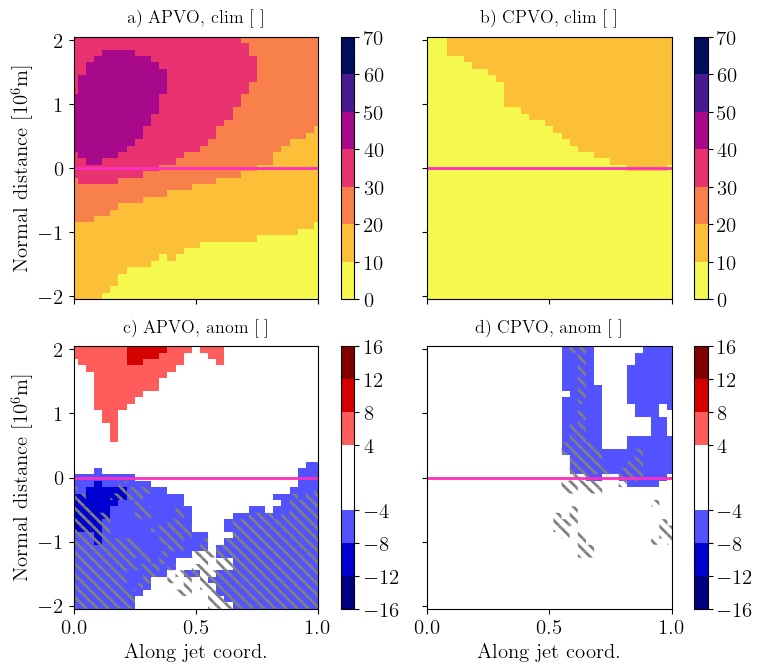

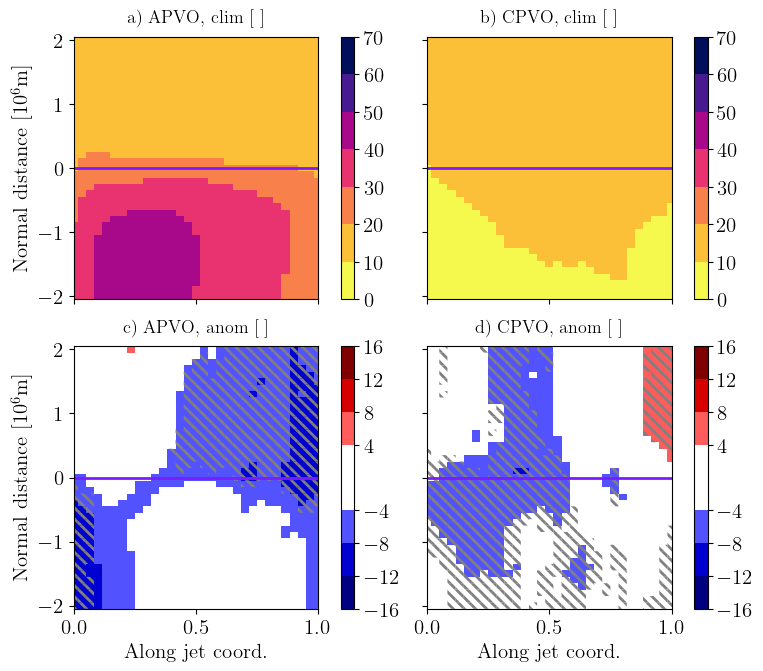

In [13]:
ipath = Path(f"{FIGURES}/Persistence/figure_data")
odir = Path(f"{FIGURES}/Persistence/RWB")
odir.mkdir(exist_ok=True)
variables = {}

for varname in ["APVO", "CPVO"]:
    variables[f"{varname}:clim"] = [8, colormaps.cet_l_bmy_r, [0, 70]]
    # variables[f"{varname}:abs"] = [8, colormaps.cet_l_bmy_r, [0, 70]]
    variables[f"{varname}:anom"] = [8, colormaps.BlWhRe, [-16, 16]]

for jet in ["STJ", "EDJ"]:
    fig = plot_interp(
        variables,
        "",
        ipath,
        jet,
        handle_pvals="hatch",
        n_col=2,
        square_len=3.3,
        transpose=True,
    )
    fig.savefig(odir.joinpath(f"{jet}.pdf"))
    # plt.close()

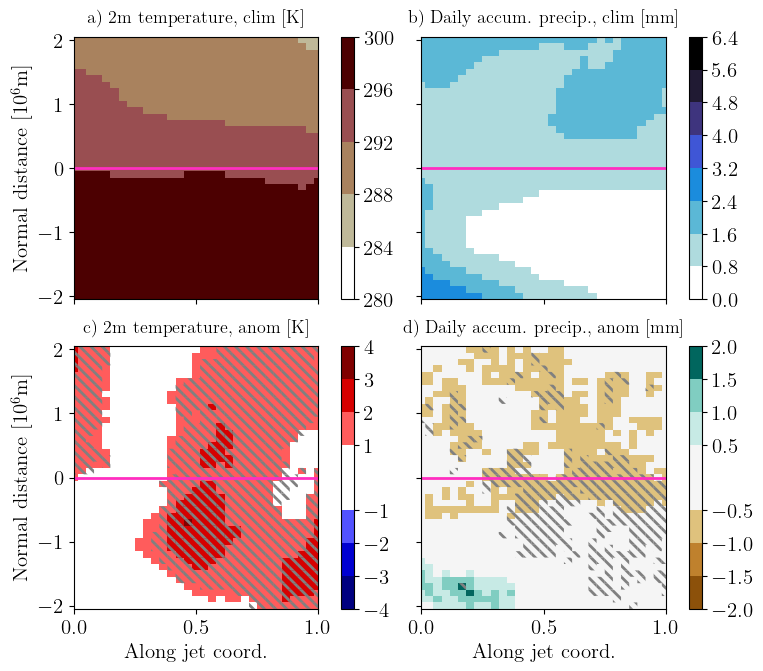

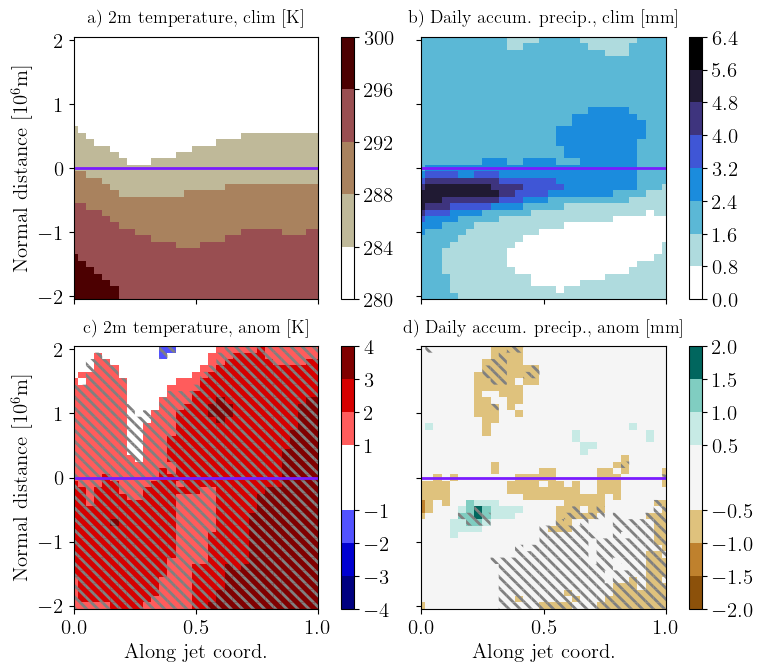

In [12]:
ipath = Path(f"{FIGURES}/Persistence/figure_data")
odir = Path(f"{FIGURES}/Persistence/ground")
odir.mkdir(exist_ok=True)
variables = {
    "t2m:clim": [6, colormaps.bilbao_r, [280, 300]],
    "t2m:anom": [8, colormaps.BlWhRe, [-4, 4]],
    "tp:clim": [9, colormaps.freeze_r, [0, 6]],
    "tp:anom": [9, colormaps.brbg, [-2, 2]],
}

for jet in ["STJ", "EDJ"]:
    fig = plot_interp(
        variables,
        "",
        ipath,
        jet,
        handle_pvals="hatch",
        n_col=2,
        square_len=3.3,
        transpose=True,
    )
    fig.savefig(odir.joinpath(f"{jet}.pdf"))
    # plt.close()

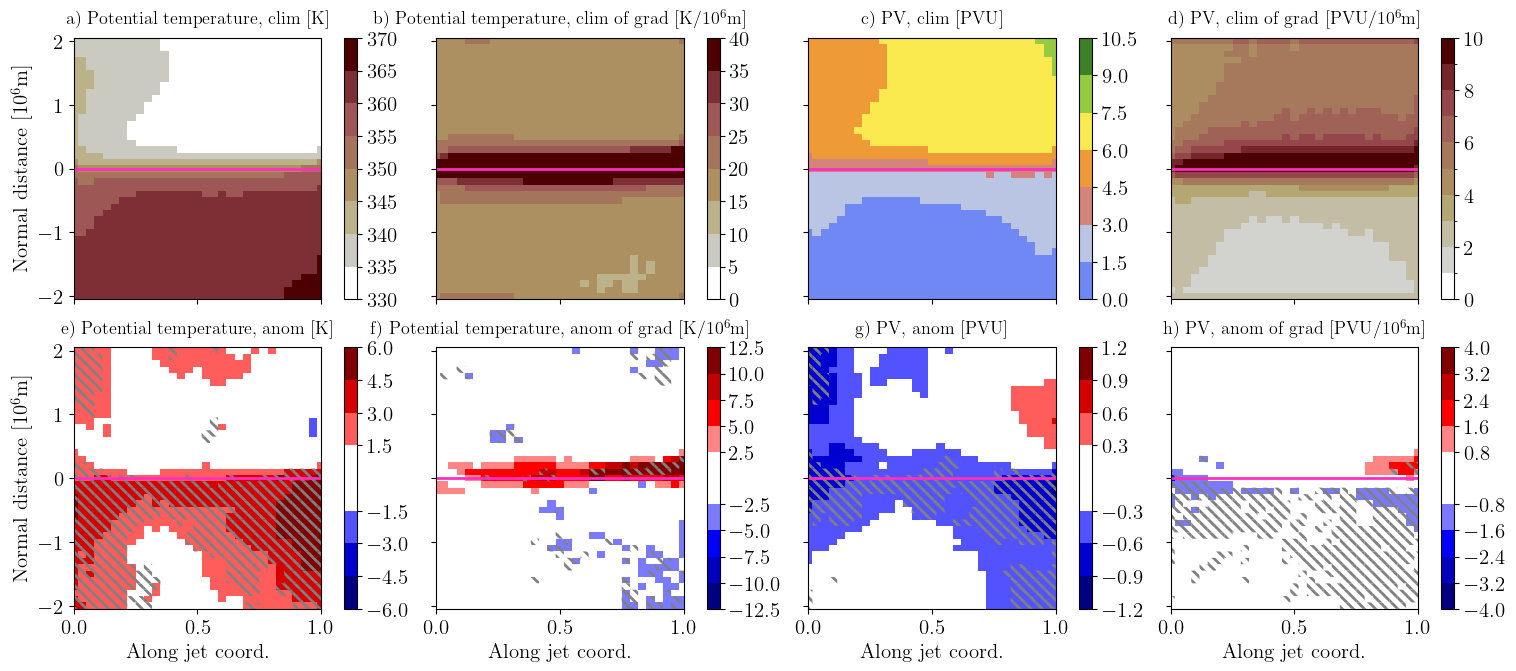

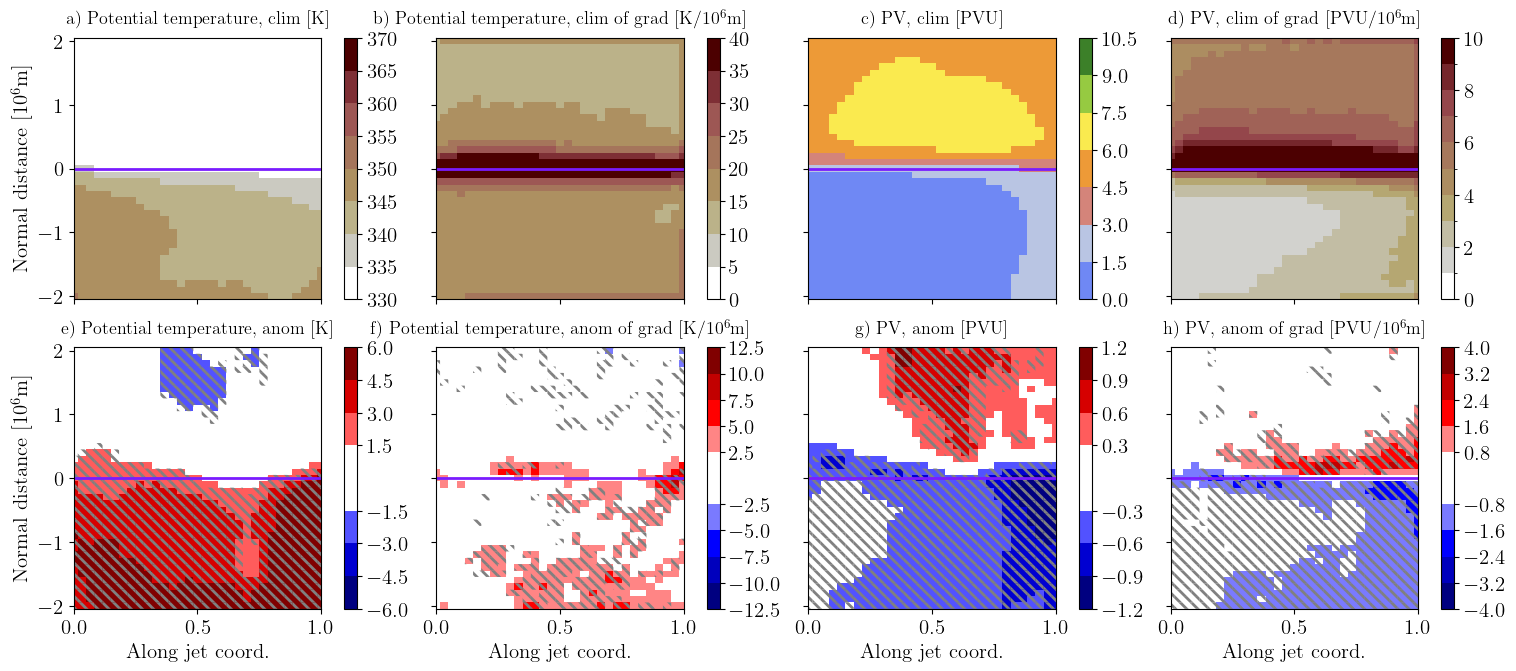

In [11]:
ipath = Path(f"{FIGURES}/Persistence/figure_data")
odir = Path(f"{FIGURES}/Persistence/upper_level")
odir.mkdir(exist_ok=True)

variables = {
    "theta:clim": [8, colormaps.bilbao_r, [330, 370]],
    "theta:anom": [8, colormaps.BlWhRe, [-6, 6]],
    "theta:clim_grad": [8, colormaps.bilbao_r, [0, 40]],
    "theta:anom_grad": [10, colormaps.BlWhRe, [-12, 12]],
    "PV:clim": [9, WERNLI_FLAIR, [0, 10]],
    "PV:anom": [8, colormaps.BlWhRe, [-1.2, 1.2]],
    "PV:clim_grad": [10, colormaps.bilbao_r, [0, 10]],
    "PV:anom_grad": [10, colormaps.BlWhRe, [-4, 4]],
}
for jet in ["STJ", "EDJ"]:
    fig = plot_interp(
        variables,
        "",
        ipath,
        jet,
        handle_pvals="hatch",
        n_col=2,
        square_len=3.3,
        transpose=True,
    )
    fig.savefig(odir.joinpath(f"{jet}.pdf"))
    # plt.close()

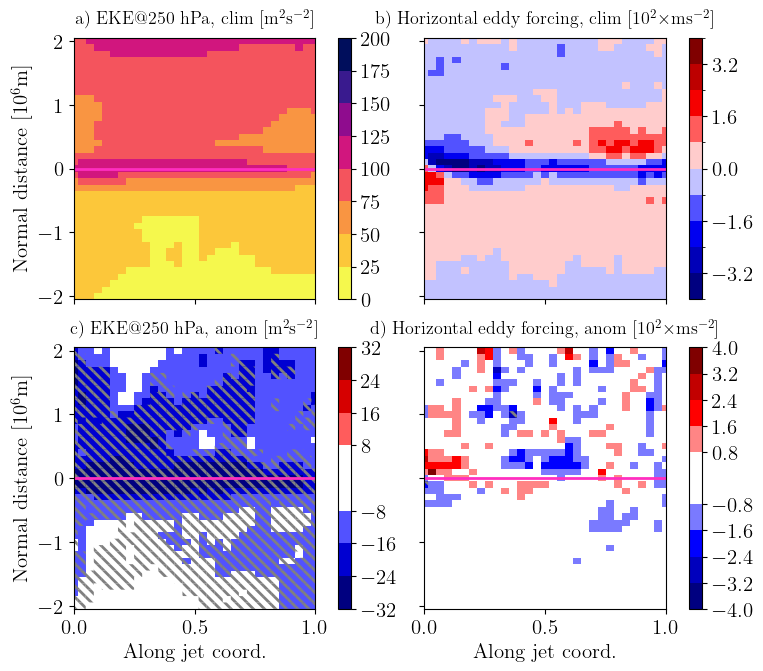

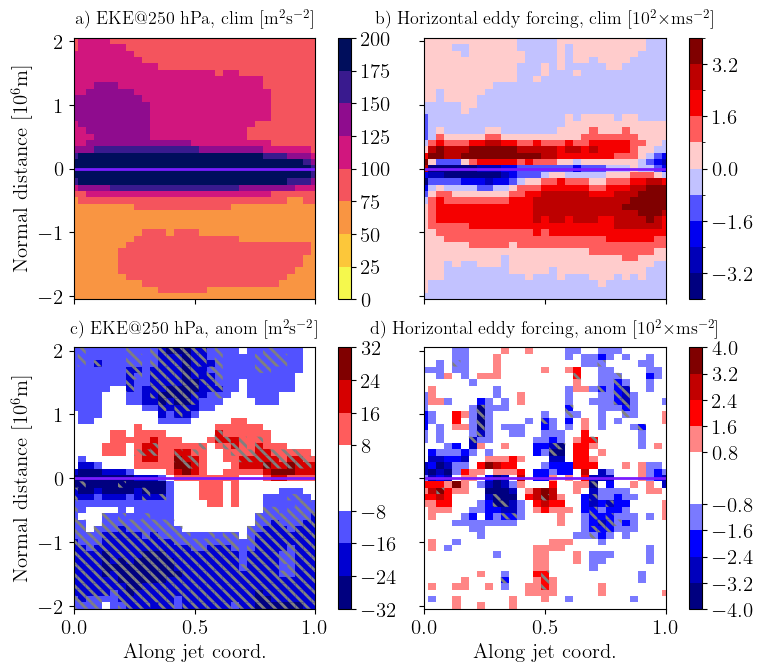

In [10]:
ipath = Path(f"{FIGURES}/Persistence/figure_data")
odir = Path(f"{FIGURES}/Persistence/eddies")
odir.mkdir(exist_ok=True)

variables = {
    "EKE250:clim": [9, colormaps.cet_l_bmy_r, [0, 200]],
    "EKE250:anom": [9, colormaps.BlWhRe, [-30, 30]],
    "hor:clim": [12, colormaps.BlWhRe, [-4, 4]],
    "hor:anom": [12, colormaps.BlWhRe, [-4, 4]],
}
for jet in ["STJ", "EDJ"]:
    fig = plot_interp(
        variables,
        "",
        ipath,
        jet,
        handle_pvals="hatch",
        n_col=2,
        square_len=3.3,
        transpose=True,
    )
    fig.savefig(odir.joinpath(f"{jet}.pdf"))
    # plt.close()

# when spells

### full grid

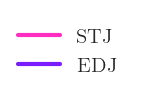

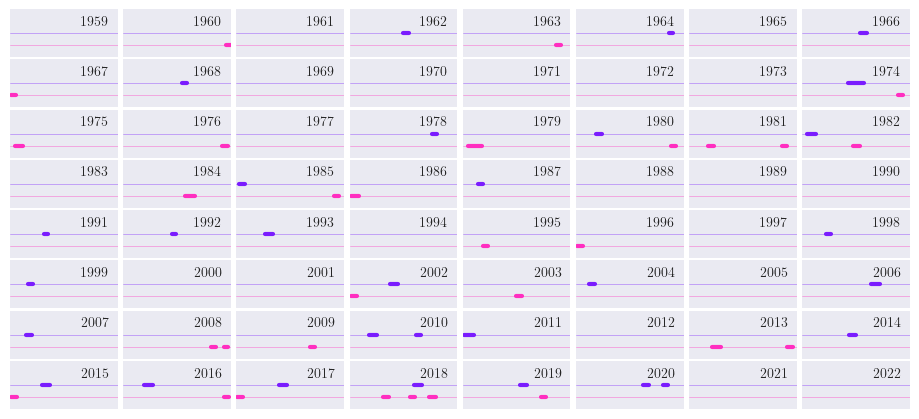

In [12]:
plt.style.use(["seaborn-v0_8-darkgrid", STYLE_SHEET])
colors = [COLORS[2], COLORS[1]]

fig, ax = plt.subplots(figsize=(1, 0.5), dpi=100)
ax.axis("off")
for spell_name, color in zip(spells_list, colors):
    ax.plot([], [], color=color, lw=3, label=spell_name)
ax.legend()
plt.show()
min_summer, max_summer = (
    summer.dt.ordinal_day().unique().first(),
    summer.dt.ordinal_day().unique().last(),
)
fig, axes = plt.subplots(
    8,
    8,
    figsize=(9, 4),
    gridspec_kw=dict(wspace=0.05, hspace=0.05, left=0, right=1, bottom=0, top=1),
    subplot_kw=dict(
        xticks=[],
        yticks=[],
        xlim=[-1, max_summer - min_summer],
        ylim=[-1, len(colors) + 1],
    ),
)
axes = axes.ravel()
for ax, year in zip(axes, YEARS):
    ax.text(70, len(spells_list) - 0.3, f"{year}", fontsize=10)
    for j, (name_, spell) in enumerate(spells_list.items()):
        ax.plot(
            [-1, max_summer - min_summer],
            [j, j],
            color=colors[j],
            lw=0.5,
            ls="solid",
            alpha=0.5,
        )
        spell_ = spell.filter(pl.col("time").dt.year() == year)
        if len(spell_) == 0:
            continue
        for s, indiv_spell in spell_.group_by("spell"):
            x = [
                indiv_spell["time"].dt.ordinal_day().first() - min_summer,
                indiv_spell["time"].dt.ordinal_day().last() - min_summer,
            ]
            y = [j, j]
            ax.plot(x, y, color=colors[j], lw=3)
plt.show()
plt.style.use(["default", STYLE_SHEET])
fig.savefig(f"{FIGURES}/Persistence/when_spells.pdf")

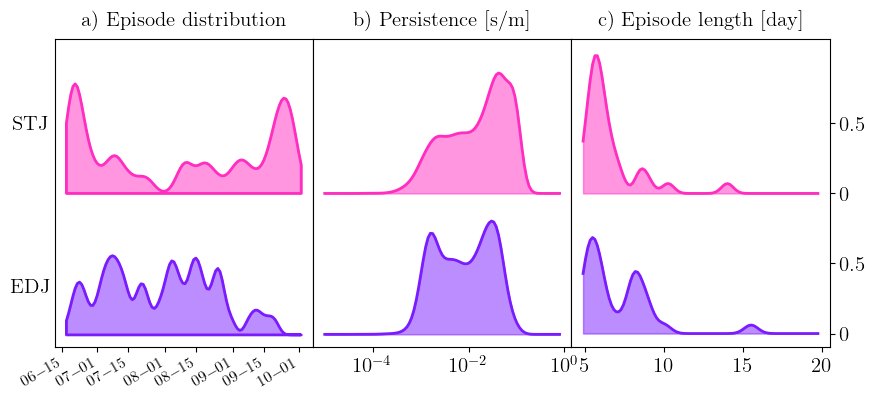

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(10, 4), gridspec_kw=dict(wspace=0, hspace=0))

ax = axes[0]
colors = [COLORS[2], COLORS[1]]
keys = list(spells_list)
i = 1
otheralpha = 0.5
dy = 30
for key, val in spells_list.items():
    huh = (
        summer.dt.ordinal_day()
        .unique()
        .sort()
        .to_frame()
        .with_columns(
            time_2=pl.datetime(year=1959, month=1, day=1) + pl.duration(days="time")
        )
    )
    to_plot = gaussian_kde(val["time"].dt.ordinal_day(), bw_method=0.08).evaluate(
        huh["time"]
    )
    ax.fill_between(
        huh["time_2"],
        i,
        i + dy * to_plot,
        color=colors[1 - i],
        facecolor="none",
        alpha=1.0,
        lw=2,
    )
    ax.fill_between(
        huh["time_2"],
        i,
        i + dy * to_plot,
        color=colors[1 - i],
        alpha=otheralpha,
    )
    i = i - 1
ax.xaxis.set_major_formatter(DateFormatter("%m-%d"))
ax.xaxis.set_tick_params(labelsize=11, rotation=30)
ticks = ax.get_xticks()
ticklabels = ax.get_xticklabels()
ax.set_xticks(ticks, labels=[t.get_text() for t in ticklabels], ha="right")
ax.set_yticks([0.35, 1.5], labels=keys[::-1])
ax.yaxis.set_tick_params(length=0)
ax.set_title("a) Episode distribution")
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], 2 - ylim[0])

ax = axes[1]
dy = 1.2
bins = np.logspace(-5.0, -0.1, 101)
cross = pers_from_cross_catd(cross)
summer_pers = summer_filter.join(cross, on="time")
y1 = summer_pers.filter(pl.col("jet ID") == 0)["pers"]
y2 = summer_pers.filter(pl.col("jet ID") == 1)["pers"]
for i, y in enumerate([y1, y2]):
    y_smo = gaussian_kde(
        np.log10(y.replace(0, None).drop_nulls()), bw_method=0.2
    ).evaluate(np.log10(bins))
    y_smo = (1 - i) + dy * y_smo
    ax.fill_between(bins, (1 - i), y_smo, color=COLORS[2 - i], alpha=otheralpha)
    ax.plot(bins, y_smo, color=COLORS[2 - i], lw=2)
ax.set_xscale("log")
ax.set_yticks([])
ax.set_title("b) Persistence [s/m]")
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], 2 - ylim[0])

ax = axes[2]
dy = 2
bins = np.arange(5, 20, 0.15) - 0.125
for i, jet in enumerate(["EDJ", "STJ"]):
    y = spells_list[jet].group_by("spell").agg(pl.col("len").first())["len"] / 4
    y_smo = gaussian_kde(y, bw_method=0.2).evaluate(bins)
    y_smo = i + dy * y_smo
    ax.fill_between(bins, i, y_smo, color=COLORS[1 + i], alpha=otheralpha)
    ax.plot(bins, y_smo, color=COLORS[1 + i], lw=2)
ax.set_yticks([0, 0.5, 1, 1.5], labels=[str(i) for i in [0, 0.5] * 2])
ax.tick_params("y", left=False, right=True, labelleft=False, labelright=True)
ax.set_title("c) Episode length [day]")
ylim = ax.get_ylim()
ax.set_ylim(ylim[0], 2 - ylim[0])
fig.savefig(f"{FIGURES}/Persistence/stats.pdf")

### with extremes

In [28]:
clusters_da = np.abs(xr.open_dataarray(basepath.joinpath("cluster_df.nc")).load())
clusters_da = clusters_da.interp(lat=np.arange(32, 72, 0.5), method="nearest")

# plt.savefig(f"{FIGURES}/jet_persistence/regions.png")

region_T = compute_anomalies_pl(
    pl.read_parquet(basepath.joinpath("region_T_6H.parquet")), ["region"]
)
region_T = region_T.rolling("time", period="3d", group_by="region").agg(
    pl.col("t2m").mean()
)
hws = get_spells(
    region_T,
    pl.col("t2m") > pl.col("t2m").quantile(0.95),
    group_by=["region"],
    fill_holes=datetime.timedelta(hours=18),
    minlen=datetime.timedelta(days=3),
).sort("region")
region_tp = compute_anomalies_pl(
    pl.read_parquet(basepath.joinpath("region_tp_6H.parquet")), ["region"]
)
region_tp = region_tp.rolling("time", period="3d", group_by="region").agg(
    pl.col("tp").mean()
)
pes = get_spells(
    region_tp,
    pl.col("tp") > pl.col("tp").quantile(0.95),
    group_by=["region"],
    fill_holes=datetime.timedelta(hours=6),
    minlen=datetime.timedelta(days=3),
).sort("region")
drs = get_spells(
    region_tp,
    pl.col("tp") < pl.col("tp").quantile(0.05),
    group_by=["region"],
    fill_holes=datetime.timedelta(hours=6),
    minlen=datetime.timedelta(days=3),
).sort("region")

NameError: name 'region_T' is not defined

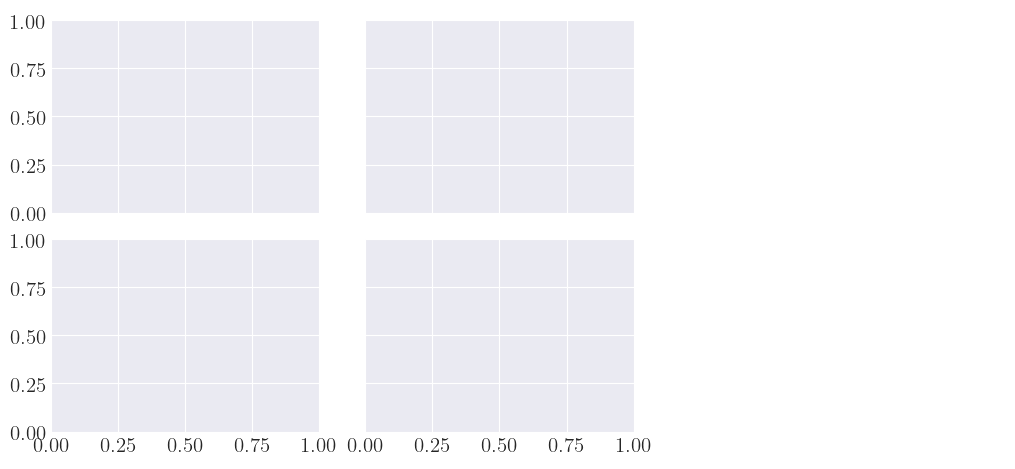

In [14]:
colors_regions = colormaps.pastel(np.linspace(0, 1, colormaps.pastel.N))[:6]
figure = plt.figure(figsize=(10, 4.5), constrained_layout=True)
subfigs = figure.subfigures(1, 2, wspace=0.00, width_ratios=[6.5, 3.5])
with plt.style.context(["seaborn-v0_8-darkgrid", STYLE_SHEET]):
    fig = subfigs[0]
    axes = fig.subplots(2, 2, sharex="col", sharey="row")
    axes = axes.T
    for i, spell_of in enumerate(["STJ", "EDJ"]):
        spells = extend_spells(daily_spells_list[spell_of])
        for j, (name, df) in enumerate({"t2m": region_T, "tp": region_tp}.items()):
            ax = axes[i, j]
            region_ts_masked = mask_from_spells_pl(
                spells, df, time_before=datetime.timedelta(days=4)
            )
            region_ts_masked = subset_around_onset(
                region_ts_masked, around_onset=datetime.timedelta(days=13)
            )
            x, alive_spells = (
                region_ts_masked.group_by(["region", "relative_index"])
                .agg(pl.col("spell").n_unique())
                .sort("relative_index")
                .filter(pl.col("region") == 1)
                .to_numpy()
                .T[1:]
            )
            filter_ = alive_spells > 3
            huh = (
                region_ts_masked.group_by(["region", "relative_index"])
                .mean()
                .sort(["region", "relative_index"])
            )
            ax.axhline(0, color="black")
            ax.axvline(0, color="black")
            for reg, huh_ in huh.group_by("region", maintain_order=True):
                y = huh_[name].to_numpy()
                y = y * 1000 if name == "tp" else y
                ax.plot(
                    x[filter_],
                    y[filter_],
                    color=colors_regions[reg[0] - 1],
                    label=DUNCANS_REGIONS_NAMES[reg[0] - 1],
                    lw=3,
                )
            k = 2 * j + i
            ax.annotate(
                f"{ascii_lowercase[k]})",
                xy=(0, 1),
                xycoords="axes fraction",
                xytext=(+0.5, -0.5 - 6.5 * float(k == 0)),
                textcoords="offset fontsize",
                fontsize="medium",
                verticalalignment="top",
                fontfamily="serif",
                bbox=dict(facecolor="0.7", edgecolor="none", pad=3.0),
            )
    # axes[0, 0].legend(ncol=2, fontsize=13.5, labelspacing=0.3, markerscale=.1, columnspacing=.6, facecolor="white", framealpha=.5, fancybox=True, frameon=True)
    axes[0, 0].set_ylabel(PRETTIER_VARNAME["t2m"])
    axes[0, 1].set_ylabel(PRETTIER_VARNAME["tp"])
    axes[0, 0].set_title("STJ episodes")
    axes[1, 0].set_title("EDJ episodes")
    axes[0, 1].set_xlabel("Time around onset [day]")
    axes[1, 1].set_xlabel("Time around onset [day]")
    ylim = axes[0, 1].get_ylim()
    for i, spell_of in enumerate(["STJ", "EDJ"]):
        spells = extend_spells(
            daily_spells_list[spell_of], time_before=datetime.timedelta(days=4)
        )
        spells = subset_around_onset(spells, around_onset=datetime.timedelta(days=13))
        x, alive_spells = (
            spells.group_by("relative_index")
            .agg(pl.col("spell").n_unique())
            .sort("relative_index")
            .to_numpy()
            .T
        )
        filter_ = alive_spells > 3
        ax = axes[i, 1]
        ybounds = [
            ylim[0] - 0.05 * (ylim[1] - ylim[0]),
            ylim[0] + 0.05 * (ylim[1] - ylim[0]),
        ]
        im = ax.pcolormesh(
            x[filter_],
            ybounds,
            alive_spells[None, filter_][:, :-1],
            zorder=-10,
            cmap=colormaps.greys,
            alpha=0.7,
            vmin=0,
        )
    axes[0, 1].set_ylim(ybounds[0])


clu = Clusterplot(1, 1, (-10, 40, 35, 72), row_height=5, fig=subfigs[1])
cmap = colormaps.pastel
ax = clu.axes[0]
unique_clusters = np.arange(1, 7)
norm = BoundaryNorm(np.arange(cmap.N) + 0.5, cmap.N)
clusters_da.assign_coords(lon=clusters_da.lon - clu.central_longitude).plot(
    ax=ax, cmap=cmap, norm=norm, add_colorbar=False, add_labels=False
)
for j in range(6):
    lo = (
        clusters_da.lon.where(clusters_da == (j + 1)).mean().item()
        - j
        - 3 * (j == 0)
        + 2 * (j == 2)
        + 3 * (j == 1)
        - (j == 4)
        - clu.central_longitude
    )
    la = clusters_da.lat.where(clusters_da == (j + 1)).mean().item() - (j == 5) * 2
    color = "black"
    ax.text(
        lo,
        la,
        DUNCANS_REGIONS_NAMES[j],
        ha="center",
        va="center",
        fontweight="bold",
        color=color,
        fontsize=12,
    )

ax.annotate(
    f"{ascii_lowercase[k + 1]})",
    xy=(float(k == 0), 1),
    xycoords="axes fraction",
    xytext=(+0.5 - 2 * float(k == 0), -0.5),
    textcoords="offset fontsize",
    fontsize="medium",
    verticalalignment="top",
    fontfamily="serif",
    bbox=dict(facecolor="0.7", edgecolor="none", pad=3.0),
)
figure.savefig(f"{FIGURES}/Persistence/region_timeseries_30spells.pdf")

In [ ]:
from matplotlib.colors import hex2color

names = ["Cyan", "Yellow", "Orange", "Purple", "Green", "Blue"]
names = [f"{name}Pastel" for name in names]
base = r"\definecolor{"
middle = r"}{rgb}{"
end = r"}"
for color, name in zip(cmap(norm(np.arange(1, 7))), names):
    color = [f"{spec:.3f}" for spec in color[:3]]
    print(base + f"{name}" + middle + " ".join(color) + end)

name = "STJcolor"
color = hex2color(COLORS[2])
color = [f"{spec:.3f}" for spec in color[:3]]
print(base + f"{name}" + middle + " ".join(color) + end)

name = "EDJcolor"
color = hex2color(COLORS[1])
color = [f"{spec:.3f}" for spec in color[:3]]
print(base + f"{name}" + middle + " ".join(color) + end)

base = r"\textcolor{"
middle = r"}{\textbf{"
end = r"}}"
schema = []
for color, name in zip(names, DUNCANS_REGIONS_NAMES):
    schema.append(base + color + middle + name + end)
print(" & ".join(schema))

\definecolor{CyanPastel}{rgb}{0.400 0.773 0.800}
\definecolor{YellowPastel}{rgb}{0.965 0.812 0.443}
\definecolor{OrangePastel}{rgb}{0.973 0.612 0.455}
\definecolor{PurplePastel}{rgb}{0.863 0.690 0.949}
\definecolor{GreenPastel}{rgb}{0.529 0.773 0.373}
\definecolor{BluePastel}{rgb}{0.620 0.725 0.953}
\definecolor{STJcolor}{rgb}{1.000 0.180 0.753}
\definecolor{EDJcolor}{rgb}{0.478 0.110 0.996}
\textcolor{CyanPastel}{\textbf{Iberian}} & \textcolor{YellowPastel}{\textbf{West.}} & \textcolor{OrangePastel}{\textbf{South.}} & \textcolor{PurplePastel}{\textbf{North.}} & \textcolor{GreenPastel}{\textbf{East.}} & \textcolor{BluePastel}{\textbf{N-E.}}


In [ ]:
def common_OR(i: int, spell_of: str) -> tuple[pl.Expr]:
    spell_c = pl.col(f"reg{i}")
    jet_c = pl.col(f"spell_{spell_of}")
    yesyes = (spell_c & jet_c).sum()
    yesno = (spell_c & ~jet_c).sum()
    noyes = (~spell_c & jet_c).sum()
    nono = (~spell_c & ~jet_c).sum()
    return yesyes, nono, noyes, yesno


def odds_ratio(i: int, spell_of: str) -> pl.Expr:
    yesyes, nono, noyes, yesno = common_OR(i, spell_of)
    OR_ = yesyes * nono / yesno / noyes
    return OR_


def is_signif_OR(i: int, spell_of: str) -> pl.Expr:
    yesyes, nono, noyes, yesno = common_OR(i, spell_of)
    OR = yesyes * nono / yesno / noyes
    SE = (1 / yesyes + 1 / nono + 1 / yesno + 1 / noyes).sqrt()
    L = OR.log()
    one_not_in_CI = ((L - 1.96 * SE).exp() > 1) | ((L + 1.96 * SE).exp() < 1)
    return one_not_in_CI


for key, df in {"hw": hws, "pe": pes, "dr": drs}.items():
    out = summer_daily.to_frame()

    for region in range(1, 7):
        alias = f"reg{region}"
        to_join = (
            df[["region", "time"]]
            .with_columns((pl.col("region") == region).alias(alias))
            .filter(alias)
            .drop("region")
        )
        out = out.join(to_join, on="time", how="left")
    for spell_of in ["STJ", "EDJ"]:
        spells = daily_spells_list[f"{spell_of}"]
        spells = (
            spells[["time", "spell"]]
            .with_columns(spell=pl.lit(True))
            .rename({"spell": f"spell_{spell_of}"})
        )
        out = out.join(spells, on="time", how="left")
    out = out.fill_null(False)

    aggs = {}
    for i, spell_of in product(range(1, 7), ["STJ", "EDJ"]):
        aggs[f"{i}{spell_of}"] = odds_ratio(i, spell_of)
        aggs[f"{i}{spell_of}_signif"] = is_signif_OR(i, spell_of)
    out = out.select(**aggs)

    out = out.to_numpy().reshape(6, 4)
    overlaps_ = out[:, [0, 2]].T
    pvals_ = out[:, [1, 3]].T

    hoho = (
        pl.DataFrame(overlaps_, schema=DUNCANS_REGIONS_NAMES)
        .with_columns([(pl.col(region)).round(1) for region in DUNCANS_REGIONS_NAMES])
        .cast({region: pl.String() for region in DUNCANS_REGIONS_NAMES})
        .with_columns(
            **{
                f"start{region}": pl.when(pl.lit(pl.Series(None, pvals_[:, i]) > 0.95))
                .then(pl.lit(r"$\mathbf{"))
                .otherwise(pl.lit(r"${"))
                for i, region in enumerate(DUNCANS_REGIONS_NAMES)
            }
        )
        .with_columns(
            **{
                region: pl.col(f"start{region}") + pl.col(region) + r"}$"
                for region in DUNCANS_REGIONS_NAMES
            }
        )
        .drop([f"start{region}" for region in DUNCANS_REGIONS_NAMES])
    )
    print(key, hoho)
    hoho.to_pandas().to_latex(
        buf=f"OR_{key}.tex",
        escape=False,
        column_format="l",
        multirow=False,
        header=True,
        index_names=False,
    )

hw shape: (2, 6)
┌────────────────┬────────────────┬─────────┬─────────┬─────────┬─────────┐
│ Iberian        ┆ West.          ┆ South.  ┆ North.  ┆ East.   ┆ N-E.    │
│ ---            ┆ ---            ┆ ---     ┆ ---     ┆ ---     ┆ ---     │
│ str            ┆ str            ┆ str     ┆ str     ┆ str     ┆ str     │
╞════════════════╪════════════════╪═════════╪═════════╪═════════╪═════════╡
│ $\mathbf{4.7}$ ┆ $\mathbf{2.4}$ ┆ ${0.3}$ ┆ ${2.1}$ ┆ ${0.0}$ ┆ ${0.0}$ │
│ ${1.4}$        ┆ ${0.6}$        ┆ ${2.0}$ ┆ ${0.0}$ ┆ ${0.0}$ ┆ ${0.0}$ │
└────────────────┴────────────────┴─────────┴─────────┴─────────┴─────────┘
pe shape: (2, 6)
┌─────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┐
│ Iberian ┆ West.   ┆ South.  ┆ North.         ┆ East.          ┆ N-E.           │
│ ---     ┆ ---     ┆ ---     ┆ ---            ┆ ---            ┆ ---            │
│ str     ┆ str     ┆ str     ┆ str            ┆ str            ┆ str            │
╞═════════╪═════════╪═════

### wrs

Text(0.5, 1.0, 'c) Monthly means')

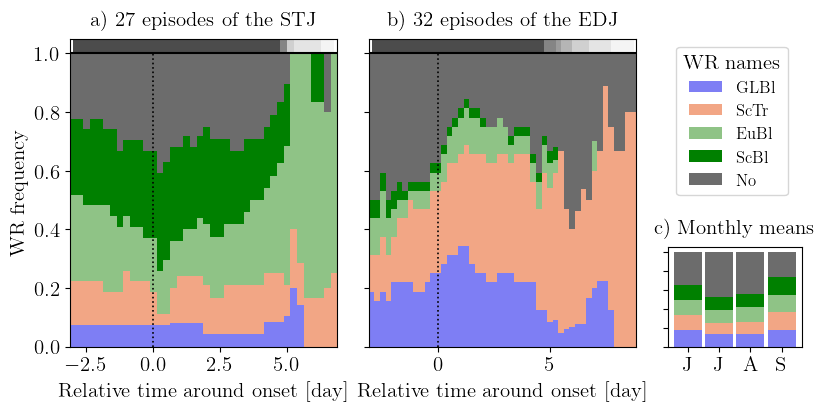

In [32]:
wr_names = ["No", "GLBl", "ScTr", "EuBl", "ScBl"]
colors = ["#6C6C6C", "#7E7EF4", "#F2A685", "#8FC386", "green"]

grams_wr = pl.read_parquet(f"{DATADIR}/grams_wr.parquet")
grams_wr = grams_wr.with_columns(
    **{
        f"winner_{i}": pl.when(pl.col("winner") == i)
        .then(pl.lit(1.0))
        .otherwise(pl.lit(0.0))
        for i in range(5)
    }
)
width = 0.25
fig, axes = plt.subplot_mosaic(
    [["a)", "b)", "c)"], ["a)", "b)", "d)"]],
    figsize=(8, 4),
    constrained_layout=True,
    sharey=True,
    width_ratios=[1, 1, 0.5],
    gridspec_kw=dict(wspace=0.1),
)
for i, (spell_of, ax) in enumerate(zip(["STJ", "EDJ"], list(axes.values()))):
    grams_wr_masked = mask_from_spells_pl(
        spells_list[spell_of], grams_wr, time_before=datetime.timedelta(days=3)
    )
    huh = grams_wr_masked.group_by(["relative_index"]).mean().sort("relative_index")
    alive_spells = (
        grams_wr_masked.group_by("relative_index")
        .agg(pl.col("spell").n_unique())
        .sort("relative_index")["spell"]
        .to_numpy()
    )
    x = huh["relative_index"].to_numpy() / 4
    filter_ = alive_spells > 3
    x = x[filter_]
    bottom = np.zeros(len(x))
    for j in [*np.arange(1, 5), 0]:
        height = huh[f"winner_{j}"].to_numpy()[filter_]
        ax.bar(
            x,
            height,
            bottom=bottom,
            facecolor=colors[j],
            width=width,
            label=wr_names[j],
        )
        bottom = bottom + height
    ax.set_xlabel("Relative time around onset [day]")
    ax.set_title(
        f"{ascii_lowercase[i]}) {alive_spells.max():n} episodes of the {spell_of[:3]}"
    )
    ax.set_xlim(x[0] - width / 2, x[-1] + width / 2)
    ybounds = [1, 1.05]
    im = ax.pcolormesh(
        x,
        ybounds,
        alive_spells[filter_][None, 1:],
        zorder=2,
        cmap=colormaps.greys,
        alpha=0.7,
        vmin=0,
    )
    ax.axhline(1, color="black")
    ax.vlines(0, 0, 1, color="black", ls="dotted", lw=1.2)
h, l = axes["b)"].get_legend_handles_labels()
axes["c)"].set_axis_off()
axes["c)"].legend(h, l, fontsize=12, ncol=1, loc="upper left", title="WR names")
axes["a)"].set_ylabel("WR frequency")
ax = axes["d)"]
monthly_means = (
    grams_wr.filter(pl.col("time").dt.month() > 5)
    .group_by(pl.col("time").dt.month())
    .agg(*[pl.col(f"winner_{i}").mean() for i in range(5)])
    .sort("time")
)
x = np.array([6, 7, 8, 9])
bottom = np.zeros(len(x))
for j in [*np.arange(1, 5), 0]:
    height = monthly_means[f"winner_{j}"].to_numpy()
    ax.bar(x, height, bottom=bottom, facecolor=colors[j], width=0.9, label=wr_names[j])
    bottom = bottom + height
ax.set_xticks(x, labels="JJAS")
ax.set_title("c) Monthly means")
# fig.savefig(f"{FIGURES}/Persistence/wrs_bars.pdf")

# props

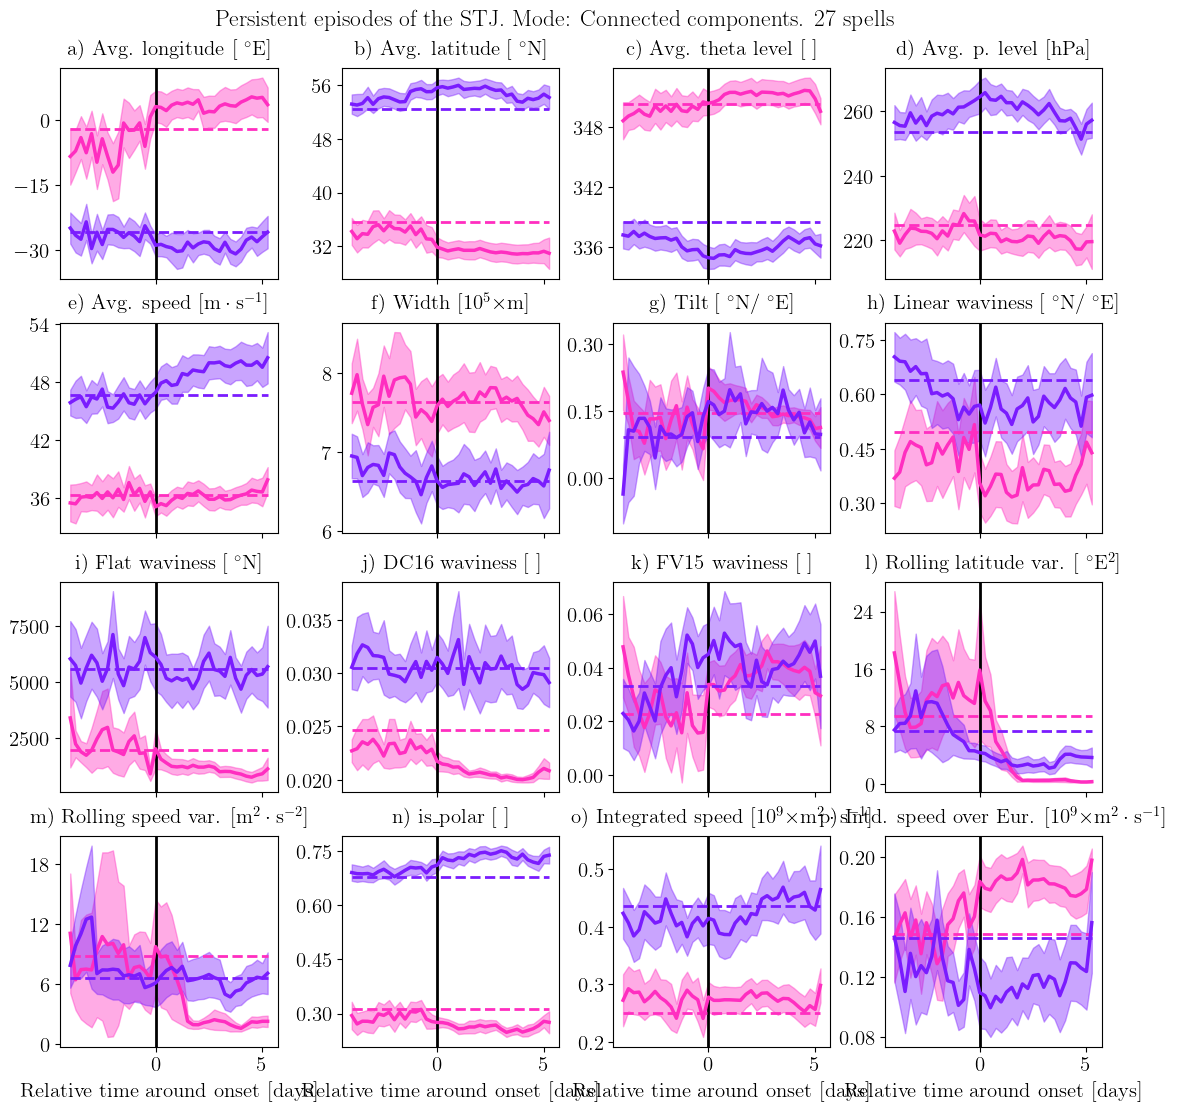

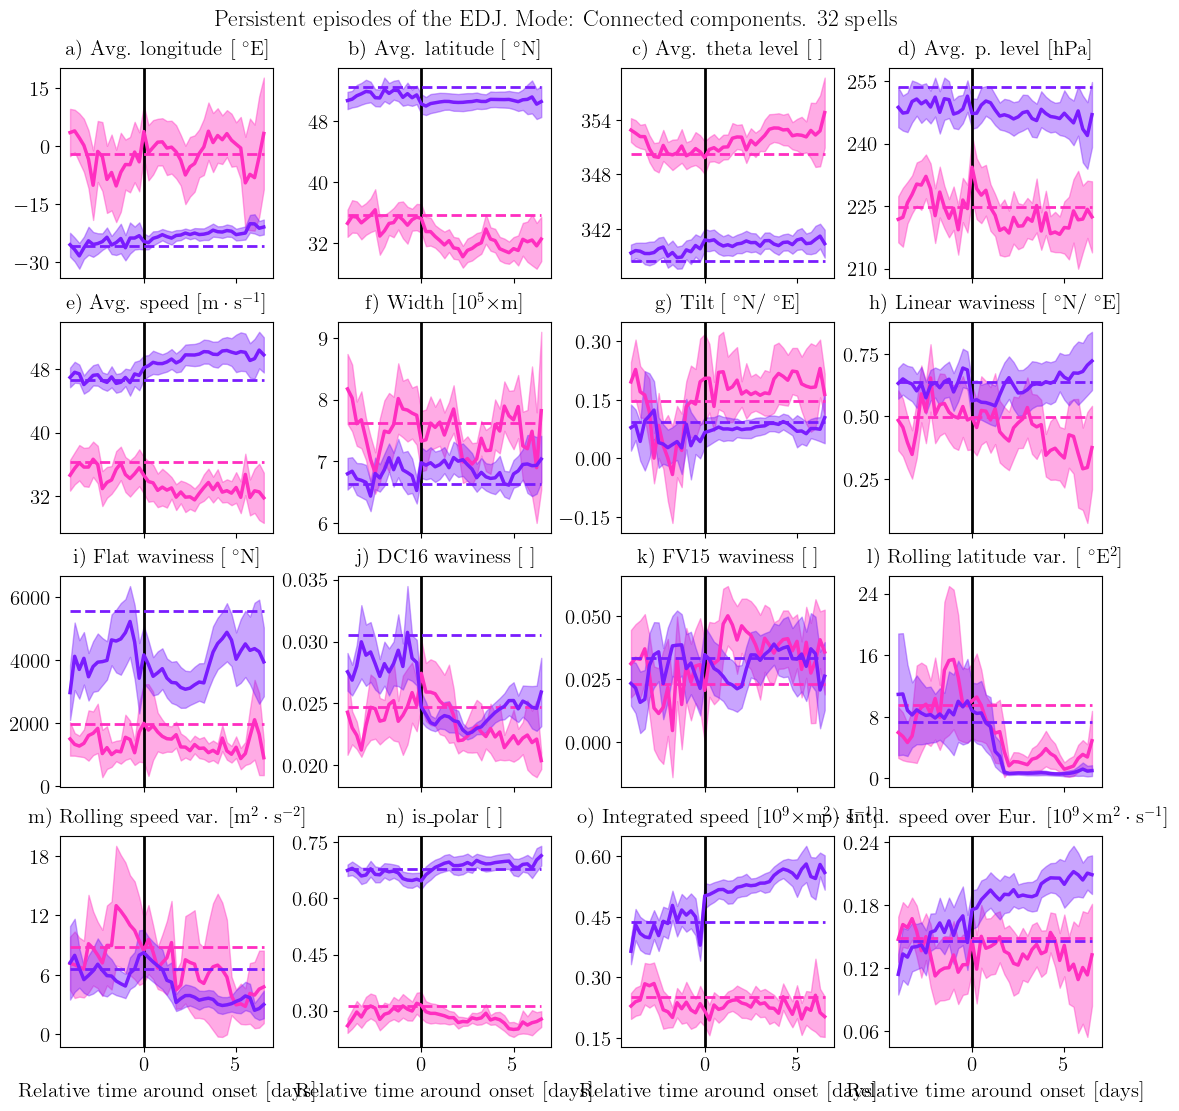

In [33]:
from string import ascii_lowercase

from scipy.stats import chi2, norm, t

data_vars = [
    "mean_lon",
    "mean_lat",
    "mean_theta",
    "mean_lev",
    "mean_s",
    "width",
    "tilt",
    "waviness1",
    "waviness2",
    "wavinessDC16",
    "wavinessFV15",
    "mean_lat_var",
    "mean_s_var",
    "is_polar",
    "int",
    "int_over_europe",
]
mode_dict = {
    "": "Connected components",
    "catd": "Full distance",
    "com": "COM distance",
}


def func(col):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).var()
    return pl.col(col).mean()


def mean_confidence(col: pl.Series, q: float) -> pl.Series:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    mu = col.mean()
    s_sq = col.var()
    if s_sq is None:
        return None
    s = np.sqrt(s_sq)
    sign = 1 - 2 * int(q < 0.5)
    q = q if q < 0.5 else 1 - q
    if n > 10:
        to_ret = mu + sign * np.abs(norm.ppf(q=q)) / np.sqrt(n) * s
    else:
        to_ret = mu + sign * s / np.sqrt(n) * t.ppf(q=1 - q, df=n - 1)
    to_ret = np.clip(to_ret, mu - 5 * s, mu + 5 * s)
    return to_ret


def var_confidence(col: pl.Series, q) -> float:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    s_sq = col.var()
    if s_sq is None:
        return None
    sign = 1 - 2 * int(q < 0.5)
    if n > 50:
        q = q if q < 0.5 else 1 - q
        to_ret = s_sq + sign * np.sqrt(2 / n) * np.abs(norm.ppf(q)) * s_sq
    else:
        to_ret = (n - 1) * s_sq / chi2.ppf(1 - q, df=n - 1)
    return np.clip(to_ret, 0, s_sq * 2)


def func_q(col, q):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).map_batches(
            partial(var_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True
        )
    return pl.col(col).map_batches(
        partial(mean_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True
    )


q_mean = 1e-15
for spell_of in ["STJ", "EDJ"]:
    spells_from_jet = spells_list[spell_of]
    n_spells = spells_from_jet["spell"].n_unique()
    props_masked = mask_from_spells_pl(
        spells_from_jet, phat_props, time_before=datetime.timedelta(days=4)
    )
    props_masked = props_masked.filter(
        pl.col("spell").n_unique().over("relative_index") > 12
    )
    aggs = {col: func(col) for col in data_vars}
    aggs = aggs | {f"{col}_10": func_q(col, q_mean) for col in data_vars}
    aggs = aggs | {f"{col}_90": func_q(col, 1 - q_mean) for col in data_vars}
    explode_list = [f"{col}_10" for col in data_vars] + [
        f"{col}_90" for col in data_vars
    ]
    aggs = aggs | {"alive": pl.col("time").len()}
    mean_ps = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
        **aggs
    )
    aggs_ = {col: func_q(col, 0.95) for col in data_vars}
    q25 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
        **aggs_
    )
    aggs_ = {col: func_q(col, 0.05) for col in data_vars}
    q75 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
        **aggs_
    )
    fig, axes = plt.subplots(4, 4, figsize=(11, 11), tight_layout=False, sharex="all")
    axes = axes.ravel()
    means = phat_props_summer.group_by("jet", maintain_order=True).agg(**aggs)
    alive_spells = (
        props_masked.group_by("relative_index")
        .agg(pl.col("spell").n_unique())
        .sort("relative_index")["spell"]
        .to_numpy()
    )
    for j, jet in enumerate(["STJ", "EDJ"]):
        to_plot = mean_ps.filter(pl.col("jet") == jet)
        q25_ = q25.filter(pl.col("jet") == jet)
        q75_ = q75.filter(pl.col("jet") == jet)
        x = to_plot["relative_index"].unique().to_numpy() / 4
        for ax, data_var, letter in zip(axes, data_vars, ascii_lowercase):
            factor = 1e9 if data_var in ["int_over_europe", "int"] else 1
            factor = 1e5 if data_var == "width" else factor
            ax.plot(x, to_plot[data_var] / factor, color=COLORS[2 - j], lw=2.5)
            ax.fill_between(
                x,
                q25_[data_var] / factor,
                q75_[data_var] / factor,
                color=COLORS[2 - j],
                alpha=0.4,
            )
            mean = means.filter(pl.col("jet") == jet)[data_var].item() / factor
            q10 = means.filter(pl.col("jet") == jet)[f"{data_var}_10"].item() / factor
            q90 = means.filter(pl.col("jet") == jet)[f"{data_var}_90"].item() / factor
            ax.plot([x[0], x[-1]], [mean, mean], color=COLORS[2 - j], ls="dashed", lw=2)
            if j == 0:
                factor_str = (
                    "" if factor == 1 else rf"$10^{int(np.log10(factor))} \times $"
                )
                ax.set_title(
                    rf"{letter}) {PRETTIER_VARNAME.get(data_var, data_var)} [{factor_str}{UNITS.get(data_var, '~')}]"
                )
            ax.yaxis.set_major_locator(MaxNLocator(4, integer=True))
    for i, ax in enumerate(axes):
        ax.axvline(0, zorder=1, color="black", lw=2)
        if i > 11:
            ax.set_xlabel("Relative time around onset [days]", color="black")
        xlim = ax.get_xlim()
        ylim = ax.get_ylim()
        ybounds = [
            ylim[0] - 0.05 * (ylim[1] - ylim[0]),
            ylim[0] + 0.05 * (ylim[1] - ylim[0]),
        ]
        # im = ax.pcolormesh(
        #     x,
        #     ybounds,
        #     alive_spells[None, :-1],
        #     zorder=-10,
        #     cmap=colormaps.greys,
        #     alpha=0.7,
        #     vmin=0,
        # )
    fig.set_constrained_layout(True)
    mode = mode_dict[spell_of[4:]]
    fig.suptitle(
        f"Persistent episodes of the {spell_of[:3]}. Mode: {mode}. {props_masked['spell'].n_unique()} spells"
    )
    # fig.savefig(f"{FIGURES}/Persistence/{spell_of}_props_{n_spells}spells.pdf")
    # plt.close()

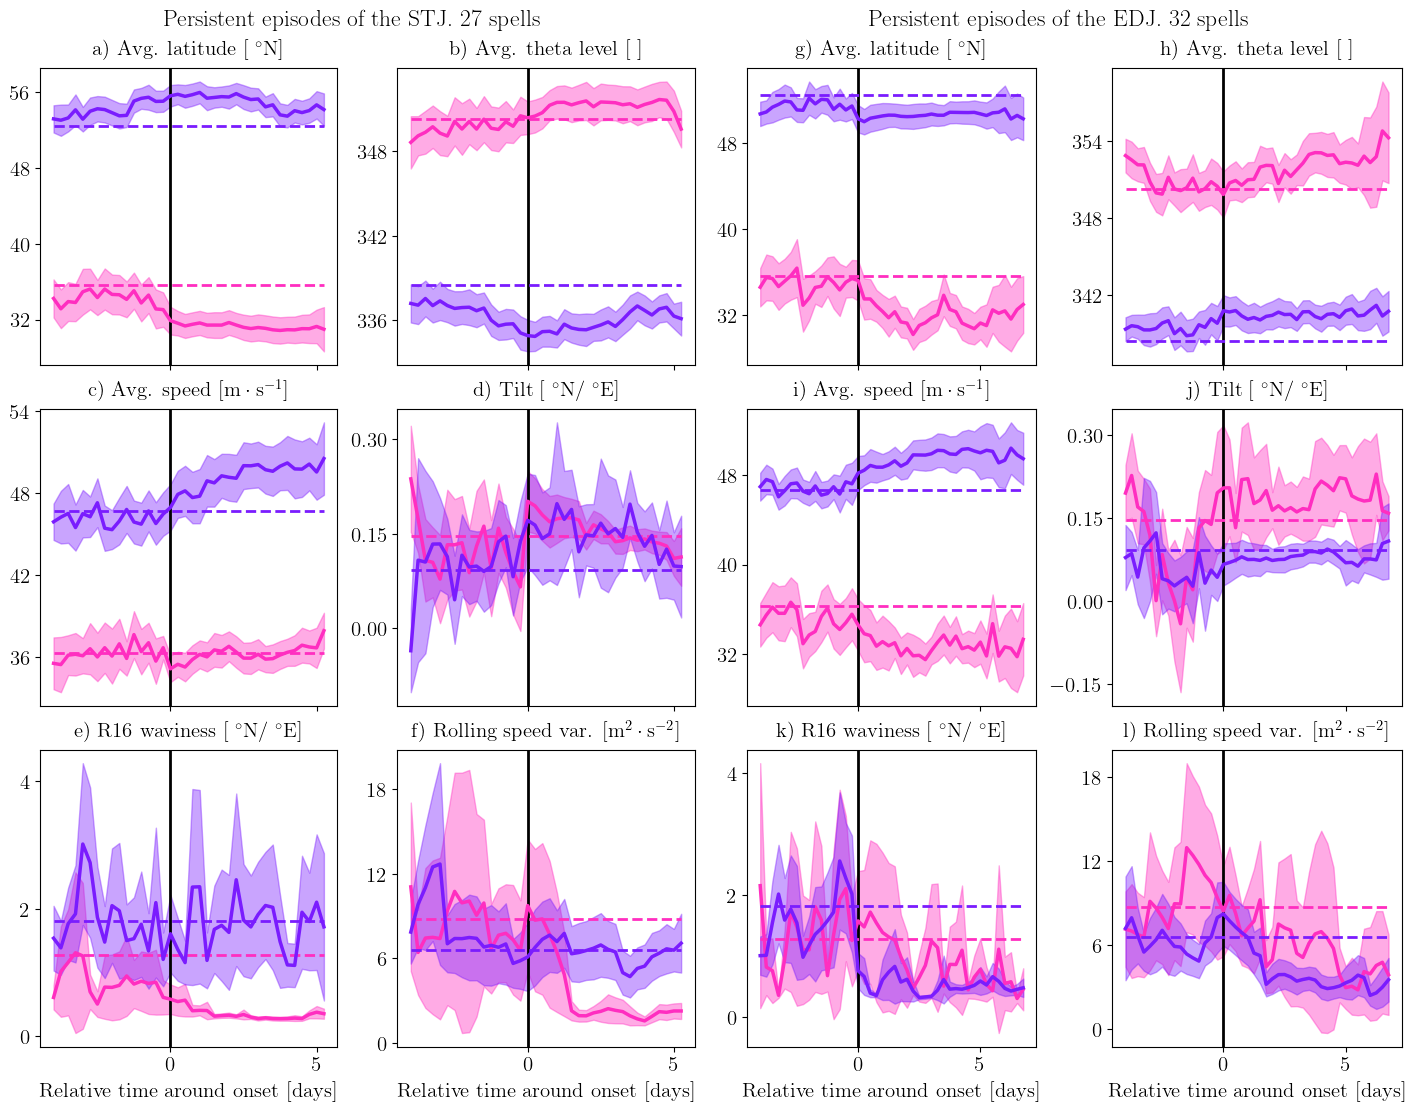

In [ ]:
from string import ascii_lowercase


data_vars = [
    "mean_lat",
    "mean_theta",
    "mean_s",
    # "width",
    "tilt",
    "wavinessR16",
    # "mean_lat_var",
    "mean_s_var",
    # "is_polar",
]
mode_dict = {
    "": "Connected components",
    "catd": "Full distance",
    "com": "COM distance",
}


def func(col):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).var()
    return pl.col(col).mean()


def mean_confidence(col: pl.Series, q: float) -> pl.Series:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    mu = col.mean()
    s_sq = col.var()
    if s_sq is None:
        return None
    s = np.sqrt(s_sq)
    sign = 1 - 2 * int(q < 0.5)
    q = q if q < 0.5 else 1 - q
    if n > 10:
        to_ret = mu + sign * np.abs(norm.ppf(q=q)) / np.sqrt(n) * s
    else:
        to_ret = mu + sign * s / np.sqrt(n) * t.ppf(q=1 - q, df=n - 1)
    to_ret = np.clip(to_ret, mu - 5 * s, mu + 5 * s)
    return to_ret


def var_confidence(col: pl.Series, q) -> float:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    s_sq = col.var()
    if s_sq is None:
        return None
    sign = 1 - 2 * int(q < 0.5)
    if n > 50:
        q = q if q < 0.5 else 1 - q
        to_ret = s_sq + sign * np.sqrt(2 / n) * np.abs(norm.ppf(q)) * s_sq
    else:
        to_ret = (n - 1) * s_sq / chi2.ppf(1 - q, df=n - 1)
    return np.clip(to_ret, 0, s_sq * 2)


def func_q(col, q):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).map_batches(
            partial(var_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True
        )
    return pl.col(col).map_batches(
        partial(mean_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True
    )


q_mean = 1e-15
for group in [["STJ", "EDJ"]]:
    group_id = mode_dict[group[0][4:]]
    bigfig = plt.figure(figsize=(14, 11), constrained_layout=True)
    subfigs = bigfig.subfigures(1, 2)
    for spell_of, fig in zip(group, subfigs):
        spells_from_jet = spells_list[spell_of]
        props_masked = mask_from_spells_pl(
            spells_from_jet, phat_props, time_before=datetime.timedelta(days=4)
        )
        props_masked = props_masked.filter(
            pl.col("spell").n_unique().over("relative_index") > 10
        )
        aggs = {col: func(col) for col in data_vars}
        aggs = aggs | {f"{col}_10": func_q(col, q_mean) for col in data_vars}
        aggs = aggs | {f"{col}_90": func_q(col, 1 - q_mean) for col in data_vars}
        explode_list = [f"{col}_10" for col in data_vars] + [
            f"{col}_90" for col in data_vars
        ]
        aggs = aggs | {"alive": pl.col("time").len()}
        mean_ps = props_masked.group_by(
            ["relative_index", "jet"], maintain_order=True
        ).agg(**aggs)
        aggs_ = {col: func_q(col, 0.95) for col in data_vars}
        q25 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
            **aggs_
        )
        aggs_ = {col: func_q(col, 0.05) for col in data_vars}
        q75 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
            **aggs_
        )
        # fig, axes = plt.subplots(3, 3, figsize=(11, 11), tight_layout=False, sharex="all")
        axes = fig.subplots(3, 2, sharex="all")
        axes = axes.ravel()
        means = phat_props_summer.group_by("jet", maintain_order=True).agg(**aggs)
        alive_spells = (
            props_masked.group_by("relative_index")
            .agg(pl.col("spell").n_unique())
            .sort("relative_index")["spell"]
            .to_numpy()
        )
        ascii_lowercase_ = ascii_lowercase[int(spell_of[:3] == "EDJ") * len(axes) :]
        for j, jet in enumerate(["STJ", "EDJ"]):
            to_plot = mean_ps.filter(pl.col("jet") == jet)
            q25_ = q25.filter(pl.col("jet") == jet)
            q75_ = q75.filter(pl.col("jet") == jet)
            x = to_plot["relative_index"].unique().to_numpy() / 4
            for ax, data_var, letter in zip(axes, data_vars, ascii_lowercase_):
                factor = 1e9 if data_var in ["int_over_europe", "int"] else 1
                factor = 1e5 if data_var == "width" else factor
                ax.plot(x, to_plot[data_var] / factor, color=COLORS[2 - j], lw=2.5)
                ax.fill_between(
                    x,
                    q25_[data_var] / factor,
                    q75_[data_var] / factor,
                    color=COLORS[2 - j],
                    alpha=0.4,
                )
                mean = means.filter(pl.col("jet") == jet)[data_var].item() / factor
                q10 = (
                    means.filter(pl.col("jet") == jet)[f"{data_var}_10"].item() / factor
                )
                q90 = (
                    means.filter(pl.col("jet") == jet)[f"{data_var}_90"].item() / factor
                )
                ax.plot(
                    [x[0], x[-1]], [mean, mean], color=COLORS[2 - j], ls="dashed", lw=2
                )
                if j == 0:
                    factor_str = (
                        "" if factor == 1 else rf"$10^{int(np.log10(factor))} \times $"
                    )
                    ax.set_title(
                        rf"{letter}) {PRETTIER_VARNAME.get(data_var, data_var)} [{factor_str}{UNITS.get(data_var, '~')}]"
                    )
                ax.yaxis.set_major_locator(MaxNLocator(4, integer=True))
        for i, ax in enumerate(axes):
            ax.axvline(0, zorder=1, color="black", lw=2)
            if i > 3:
                ax.set_xlabel("Relative time around onset [days]", color="black")
            xlim = ax.get_xlim()
            ylim = ax.get_ylim()
            ybounds = [
                ylim[0] - 0.05 * (ylim[1] - ylim[0]),
                ylim[0] + 0.05 * (ylim[1] - ylim[0]),
            ]
            # im = ax.pcolormesh(
            #     x,
            #     ybounds,
            #     alive_spells[None, :-1],
            #     zorder=-10,
            #     cmap=colormaps.greys,
            #     alpha=0.7,
            # )
        mode = mode_dict[spell_of[4:]]
        fig.suptitle(
            f"Persistent episodes of the {spell_of[:3]}. {props_masked['spell'].n_unique()} spells"
        )
    # bigfig.savefig(f"{FIGURES}/Persistence/both_props_30spells.pdf")
    # plt.close()

### reduced

Text(0.5, 0.98, 'Persistent episodes of the EDJ. 32 spells')

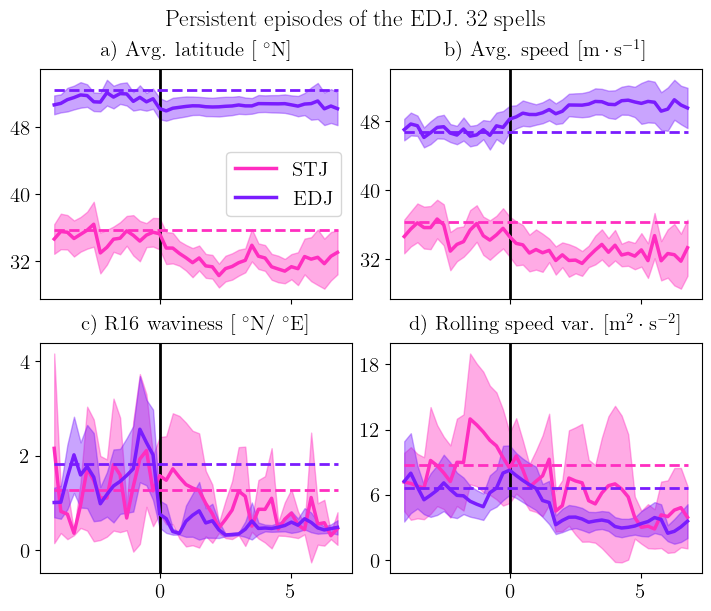

In [ ]:
from string import ascii_lowercase

from scipy.stats import chi2, norm, t

data_vars = [
    "mean_lat",
    # "mean_theta",
    "mean_s",
    # "width",
    # "tilt",
    "wavinessR16",
    # "mean_lat_var",
    "mean_s_var",
    # "is_polar",
]


def func(col):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).var()
    return pl.col(col).mean()


def mean_confidence(col: pl.Series, q: float) -> pl.Series:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    mu = col.mean()
    s_sq = col.var()
    if s_sq is None:
        return None
    s = np.sqrt(s_sq)
    sign = 1 - 2 * int(q < 0.5)
    q = q if q < 0.5 else 1 - q
    if n > 10:
        to_ret = mu + sign * np.abs(norm.ppf(q=q)) / np.sqrt(n) * s
    else:
        to_ret = mu + sign * s / np.sqrt(n) * t.ppf(q=1 - q, df=n - 1)
    to_ret = np.clip(to_ret, mu - 5 * s, mu + 5 * s)
    return to_ret


def var_confidence(col: pl.Series, q) -> float:
    n = (col.is_not_null() & col.is_not_nan()).sum()
    s_sq = col.var()
    if s_sq is None:
        return None
    sign = 1 - 2 * int(q < 0.5)
    if n > 50:
        q = q if q < 0.5 else 1 - q
        to_ret = s_sq + sign * np.sqrt(2 / n) * np.abs(norm.ppf(q)) * s_sq
    else:
        to_ret = (n - 1) * s_sq / chi2.ppf(1 - q, df=n - 1)
    return np.clip(to_ret, 0, s_sq * 2)


def func_q(col, q):
    if ":" in col and col.split(":")[-1] == "var":
        return pl.col(col.split(":")[0]).map_batches(
            partial(var_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True
        )
    return pl.col(col).map_batches(
        partial(mean_confidence, q=q), return_dtype=pl.Float64(), returns_scalar=True
    )


q_mean = 1e-15
spell_of = "EDJ"
fig, axes = plt.subplots(2, 2, figsize=(7, 6), constrained_layout=True, sharex="all")
spells_from_jet = spells_list[spell_of]
props_masked = mask_from_spells_pl(
    spells_from_jet, phat_props, time_before=datetime.timedelta(days=4)
)
props_masked = props_masked.filter(
    pl.col("spell").n_unique().over("relative_index") > 10
)
aggs = {col: func(col) for col in data_vars}
aggs = aggs | {f"{col}_10": func_q(col, q_mean) for col in data_vars}
aggs = aggs | {f"{col}_90": func_q(col, 1 - q_mean) for col in data_vars}
explode_list = [f"{col}_10" for col in data_vars] + [f"{col}_90" for col in data_vars]
aggs = aggs | {"alive": pl.col("time").len()}
mean_ps = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(
    **aggs
)
aggs_ = {col: func_q(col, 0.95) for col in data_vars}
q25 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(**aggs_)
aggs_ = {col: func_q(col, 0.05) for col in data_vars}
q75 = props_masked.group_by(["relative_index", "jet"], maintain_order=True).agg(**aggs_)
axes = axes.ravel()
means = phat_props_summer.group_by("jet", maintain_order=True).agg(**aggs)
alive_spells = (
    props_masked.group_by("relative_index")
    .agg(pl.col("spell").n_unique())
    .sort("relative_index")["spell"]
    .to_numpy()
)
ascii_lowercase_ = ascii_lowercase
for j, jet in enumerate(["STJ", "EDJ"]):
    to_plot = mean_ps.filter(pl.col("jet") == jet)
    q25_ = q25.filter(pl.col("jet") == jet)
    q75_ = q75.filter(pl.col("jet") == jet)
    x = to_plot["relative_index"].unique().to_numpy() / 4
    for ax, data_var, letter in zip(axes, data_vars, ascii_lowercase_):
        factor = 1e9 if data_var in ["int_over_europe", "int"] else 1
        factor = 1e5 if data_var == "width" else factor
        ax.plot(x, to_plot[data_var] / factor, color=COLORS[2 - j], lw=2.5, label=jet)
        ax.fill_between(
            x,
            q25_[data_var] / factor,
            q75_[data_var] / factor,
            color=COLORS[2 - j],
            alpha=0.4,
        )
        mean = means.filter(pl.col("jet") == jet)[data_var].item() / factor
        q10 = means.filter(pl.col("jet") == jet)[f"{data_var}_10"].item() / factor
        q90 = means.filter(pl.col("jet") == jet)[f"{data_var}_90"].item() / factor
        ax.plot([x[0], x[-1]], [mean, mean], color=COLORS[2 - j], ls="dashed", lw=2)
        if j == 0:
            factor_str = "" if factor == 1 else rf"$10^{int(np.log10(factor))} \times $"
            ax.set_title(
                rf"{letter}) {PRETTIER_VARNAME.get(data_var, data_var)} [{factor_str}{UNITS.get(data_var, '~')}]"
            )
        ax.yaxis.set_major_locator(MaxNLocator(4, integer=True))
for i, ax in enumerate(axes):
    ax.axvline(0, zorder=1, color="black", lw=2)
    if i > 3:
        ax.set_xlabel("Relative time around onset [days]", color="black")
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    ybounds = [
        ylim[0] - 0.05 * (ylim[1] - ylim[0]),
        ylim[0] + 0.05 * (ylim[1] - ylim[0]),
    ]
    # im = ax.pcolormesh(
    #     x,
    #     ybounds,
    #     alive_spells[None, :-1],
    #     zorder=-10,
    #     cmap=colormaps.greys,
    #     alpha=0.7,
    # )
axes[0].legend()
fig.suptitle(
    f"Persistent episodes of the {spell_of[:3]}. {props_masked['spell'].n_unique()} spells"
)
# fig.savefig(f"{FIGURES}/Persistence/EDJ_props_reduced_30spells.pdf")

# realspace from data

In [36]:
figure_data = f"{FIGURES}/Persistence/figure_data/realspace_fig06"
data_contour = xr.open_dataarray(f"{figure_data}/contour.nc")
data_signif = xr.open_dataset(f"{figure_data}/signifs.nc")
data_wind = xr.open_dataset(f"{figure_data}/wind.nc")
data_contourf = xr.open_dataset(f"{figure_data}/contourf.nc")

long_names = {
    "t2m": "2m temperature [K]",
    "t_up": "Upper level temperature [K]",
    "tp": "Daily accum. precip. [mm]",
    "apvs": r"Anticyclonic PV streamer freq [$\%$]",
    "cpvs": r"Cyclonic PV streamer freq [$\%$]",
    "s": r"Wind speed [$\mathrm{m.s}^{-1}$]",
    "theta": "Pot temp at 2 PVU [K]",
    "z200": "Z200 anomaly [m]",
    "z500": "Z500 anomaly [m]",
    "pv330": "PV at 330K [PVU]",
    "pv350": "PV at 350K [PVU]",
}

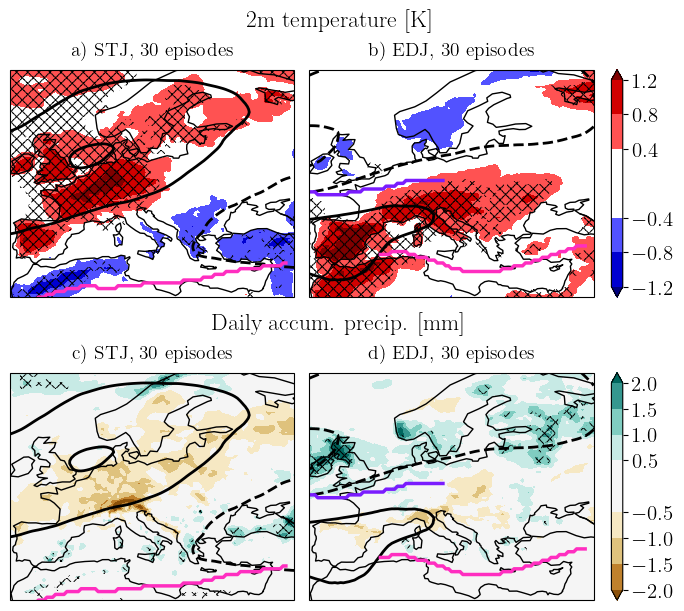

In [ ]:
from jetutils.jet_finding import find_all_jets
from string import ascii_lowercase

from cartopy.mpl.geoaxes import GeoAxes

plt.rc("axes", titlesize=14)
cbar_kwargs = {"shrink": 1.0, "fraction": 0.11, "pad": 0.03}
plot_kwargs_1 = {
    "cmap": colormaps.BlWhRe,
    "levels": [-1.2, -0.8, -0.4, 0.4, 0.8, 1.2],
    "transparify": 1,
    "cbar_kwargs": cbar_kwargs,
}
plot_kwargs_2 = {
    "cmap": colormaps.brbg,
    "levels": np.linspace(-2, 2, 9).tolist(),
    "transparify": 0,
    "cbar_kwargs": cbar_kwargs,
}
stippling_kwargs = {
    "FDR": True,
    "invert": False,
    "linewidth": 0.7,
    "color": "black",
    "hatch": "xxx",
}
nrow, ncol = 1, 2
days_around = 3
n = nrow * ncol
cmap = colormaps.pastel
norm = BoundaryNorm(np.arange(cmap.N) + 0.5, cmap.N)
bigfig = plt.figure(figsize=(6.8, 6), constrained_layout=True)
subfigs = bigfig.subfigures(2, 1)
for varname, plot_kwargs, fig in zip(
    ["t2m", "tp"], [plot_kwargs_1, plot_kwargs_2], subfigs
):
    clu = Clusterplot(nrow, ncol, get_region(data_contourf[varname]), fig=fig)
    titles = []
    for j, jet in enumerate(spells_list):
        letter = ascii_lowercase[
            j % len(ascii_lowercase) + len(clu.axes) * int(varname == "tp")
        ]
        n_spells = daily_spells_list[jet]["spell"].n_unique()
        titles.append(f"{letter}) {jet[:3]}, {n_spells} episodes")
    clu.add_contourf(data_contourf[varname], titles=titles, **plot_kwargs)
    clu.add_stippling(data_signif[varname].astype(bool), **stippling_kwargs)
    clu.add_contour(
        data_contour, levels=[-60, -20, 20, 60], linewidths=2.0, clabels=False
    )
    fig.suptitle(long_names[varname])

jets_on_mean = find_all_jets(data_wind, n_coarsen=1)
for fig in subfigs:
    for ax, (_, jets) in zip(fig.axes, jets_on_mean.group_by("relative_index")):
        if not isinstance(ax, GeoAxes):
            continue
        for _, jet_ in jets.group_by("jet ID"):
            lo, la = jet_[["lon", "lat"]]
            if la.mean() > 40:
                color = COLORS[1]
            else:
                color = COLORS[2]
            ax.plot(lo - clu.central_longitude, la, lw=2.5, color=color)
bigfig.savefig(f"{FIGURES}/Persistence/t2m_and_tp_realspace_both_30spells.pdf")

# WB

In [84]:
summer_doy = summer_daily.dt.ordinal_day().unique()
n_bootstraps = 100

cold = pl.col("n") >= 0
warm = pl.col("n") <= 0
reduced = pl.col("n").abs() <= 1e6
mid = [pl.col("norm_index") >= 0.33, pl.col("norm_index") <= 0.66]
entrance = pl.col("norm_index") <= 0.33
exit_ = pl.col("norm_index") >= 0.66

all_region_filters = {
    "cold": [cold, reduced],
    "warm": [warm, reduced],
    "cold_entrance": [cold, entrance, reduced],
    "warm_entrance": [warm, entrance, reduced],
    "cold_mid": [cold, *mid, reduced],
    "warm_mid": [warm, *mid, reduced],
    "cold_exit": [cold, exit_, reduced],
    "warm_exit": [warm, exit_, reduced],
    "core": [pl.col("n").abs() <= 5e5],
    "warm_far": [pl.col("n") <= -1.2e6, pl.col("norm_index") <= 0.5],
}
filters_for_variables = {
    "APVO": [
        "cold_entrance",
        "warm_entrance",
        "cold_mid",
        "warm_mid",
        "cold_exit",
        "warm_exit",
    ],
    "CPVO": [
        "cold_entrance",
        "warm_entrance",
        "cold_mid",
        "warm_mid",
        "cold_exit",
        "warm_exit",
    ],
    # "hor": ["cold", "warm", "core"],
}
time_filters = {
    "before": [
        pl.col("relative_time") < pl.duration(days=0),
        pl.col("relative_time") >= pl.duration(days=-4),
    ],
    "during": [
        pl.col("relative_time") >= pl.duration(days=0),
        pl.col("relative_time") <= pl.duration(days=5),
    ],
}
do_anom = {
    "APVO": False,
    "CPVO": False,
    # "hor": True,
}

# relative_dfs = {}
# clims = {}
# clims_std = {}
# clims_sm = {}
all_to_plot = {}
all_pvals = {}
all_to_plot["spell"] = pl.Series(np.arange(30))
all_pvals["spell"] = pl.Series(np.arange(30))
for varname in tqdm(filters_for_variables):
    varname_ = f"{varname}_interp"
    df = summer_filter.lazy().join(
        pl.scan_parquet(basepath.joinpath(f"{varname}_relative.parquet")).cast(
            {"time": pl.Datetime("ms")}
        ),
        on="time",
    )
    if varname == "hor":
        df = df.drop("hor1_interp", "hor2_interp")
    these_filters = {
        name: all_region_filters[name] for name in filters_for_variables[varname]
    }
    for filter_name, filter_ in these_filters.items():
        df_ = df.filter(filter_)
        df_ = df_.group_by("time", "jet ID").agg(pl.col(varname_).any())
        full_title = f"{varname}_{filter_name}"
        df_ = squarify(df_.collect(), ("time", "jet ID")).with_columns(
            pl.col(varname_).fill_null(False)
        )
        # relative_dfs[full_title] = df_
        clim = (
            df_.group_by(
                pl.col("time").dt.ordinal_day().alias("dayofyear"),
                "jet ID",
            )
            .agg(pl.col(f"{varname}_interp").mean())
            .sort("dayofyear", "jet ID")
        )
        winsize = 31
        halfwinsize = 15
        clim = clim.rolling(
            pl.col("dayofyear").cast(pl.UInt32()),
            period=f"{winsize}i",
            offset=f"-{halfwinsize + 1}i",
            group_by="jet ID",
        ).agg(pl.col(varname_).mean())
        # clims[full_title] = clim
        times = create_bootstrapped_times(spells, summer, n_bootstraps)
        anoms = (
            df_.join(
                clim,
                left_on=[pl.col("time").dt.ordinal_day(), "jet ID"],
                right_on=["dayofyear", "jet ID"],
            )
            .drop("jet ID_right")
            .with_columns(pl.col(varname_) - pl.col(f"{varname_}_right"))
            .drop(f"{varname_}_right")
        )
        to_plot = (
            times
            .join(anoms, on="time")
            .group_by("sample_index", "spell")
            .agg(pl.col(varname_).mean())
            .sort("sample_index", "spell")
        )
        pvals = (
            to_plot.group_by("spell", maintain_order=True)
            .agg((pl.col(varname_).rank().last() - 1) / n_bootstraps)
            .with_columns(
                **{varname_: 2 * pl.min_horizontal(pl.col(varname_), 1 - pl.col(varname_))}
            )
            .sort("spell")
        )
        to_plot = (
            to_plot
            .filter(pl.col("sample_index") == n_bootstraps)
            .drop("sample_index")
        )
        all_to_plot[full_title] = to_plot[varname_]
        all_pvals[full_title] = pvals[varname_]
    # clim_std = (
    #     df.group_by(
    #         pl.col("time").dt.ordinal_day().alias("dayofyear"),
    #         "norm_index",
    #         "n",
    #         "jet ID",
    #     )
    #     .agg(pl.col(f"{title}_interp").std())
    #     .sort("jet ID", "dayofyear", "norm_index", "n")
    #     .collect()
    # )
    # clims_std[title] = clim_std
    # clim_sm = clim.with_columns(
    #     **{
    #         f"{title}_interp": pl.col(f"{title}_interp")
    #         .filter(pl.col("dayofyear").is_in(summer_doy.implode()))
    #         .mean()
    #         .over("jet ID", "n", "norm_index")
    #     }
    # )
    # clims_sm[title] = clim_sm

100%|██████████| 2/2 [00:03<00:00,  1.81s/it]


In [89]:
pvals < 0.05

<xarray.DataArray (variable: 12, spell: 30)> Size: 360B
array([[False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False],
       [False,  True, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True,  True, False],
       [False,  True, False, False,  True, False, False,  True, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False,  True, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False,  True, False],
       [False, False, False,  True,  True, False, False,  True, False,
        False, False, False, False, False, False, False, False,  True,
        False, False, False, False,  True, False, False, False, False,
        False, False, False],
...
       [False, False, False, False, False, False, False,  True, False,
         True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
         True, False, False],
       [False, False, False, False, False, False, False, False, False,
         True, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False,  True, False,
        False, False, False,  True,  True, False, False, False, False,
        False, False, False, False, False, False, False, False,  True,
         True,  True, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False, False],
       [False, False, False, False, False, False, False, False, False,
        False, False, False, False, False, False, False, False, False,
        False, False,  True, False, False, False, False, False, False,
        False, False, False]])
Coordinates:
  * variable  (variable) object 96B 'APVO_cold_entrance' ... 'CPVO_warm_exit'
  * spell     (spell) int64 240B 0 1 2 3 4 5 6 7 8 ... 22 23 24 25 26 27 28 29

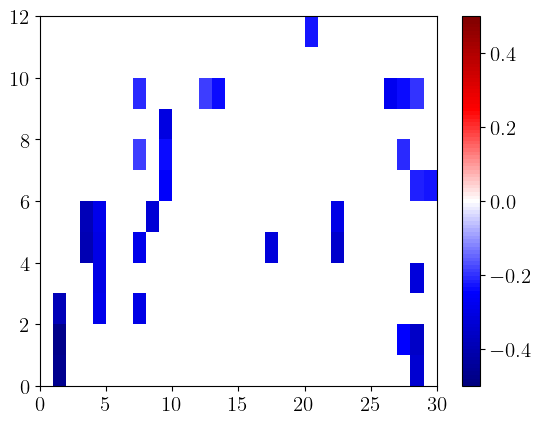

In [96]:
da = polars_to_xarray(pl.DataFrame(all_to_plot), ["spell"]).to_array()
pvals = polars_to_xarray(pl.DataFrame(all_pvals), ["spell"]).to_array()

huh = plt.pcolormesh(da.where(pvals < 0.05), cmap=colormaps.BlWhRe, vmin=-0.5, vmax=0.5)
plt.colorbar(huh)
